In [ ]:
import os
import numpy as np
import pandas as pd
import scipy

from IPython.display import display
from tqdm.auto import tqdm

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt

from src.data_utils import (
    remove_duplicate_texts,
    load_vader_words,
    load_gervader_words,
)

from src.preprocessing import run_preprocessing_loop

from src.model_utils import (
    vectorize,
    tune_lda_models,
    tune_lsa_models,
    build_sentiment_df,
    get_selected_topic_model,
    compute_dominant_topics,
    merge_topic_sentiment,
    build_topic_sentiment_summary
)

from src.visualization import (
    display_tuning_results,
    display_topic_model_summary,
    plot_topic_words,
    plot_topic_sizes,
    compare_topic_sizes,
    plot_topic_overlap_matrix,
    plot_topic_sentiment,
    show_reviews_for_topic,
    style_topic_sentiment,
)

In [2]:
##########
# Data Import
##########

# Variable Definition
local_dir = "data"
path_reviews = f"{local_dir}/combined_reviews.csv"
stopword_path = "data/stopwords_custom.json"

# Import data to pandas dataframe
df_reviews = pd.read_csv(path_reviews)

df_reviews["language"] = df_reviews["origin"].map({
    "FragdenStaat": "de",
    "YELP": "en",
})

# Remove duplicate Requests
df_reviews = remove_duplicate_texts(df_reviews, text_col="review")


##########
# Stopword Definition
##########

# Import Sentiment Stopwords based on threshold
sia_en = SentimentIntensityAnalyzer()
de_thres = 2
en_thres = 1.5

vader_words_en = load_vader_words(sia_en, en_thres)
gervader_words_de = load_gervader_words("GerVADER/GERVaderLexicon.txt", de_thres)

# Build Basis-Dictionary
dict_stopw_default = {
    "iter_0": {
        "de_nltk_common": stopwords.words("german"),
        "de_vader_topic_only":gervader_words_de,
        "en_nltk_common": stopwords.words("english"),
        "en_vader_topic_only":vader_words_en,
        
    },
    "iter_1": {
        "de_custom_common": [],
        "de_custom_topic_only": [],
        "en_custom_common": [],
        "en_custom_topic_only": []
    }
}


=== Duplicate Removal ===
Before: 2000 rows
After:  1749 rows
Removed: 251 duplicates


In [3]:
##########
# Data PreProcessing
##########

top_n = 30       # Number of top tokens to display
n_process = 1    # Number of parallel processes (performance tuning)


# Run interactive preprocessing pipeline:
# - Loads or initializes stopword configuration (JSON)
# - Applies iterative stopword refinement (user-guided)
# - Cleans and tokenizes text for both topic modeling and sentiment analysis
# - Displays top token comparisons for validation
# - Repeats until user confirms final stopw

data_topic, data_sentiment, dict_stopw = run_preprocessing_loop(
    df_reviews=df_reviews,
    stopword_path=stopword_path,
    dict_stopw_default=dict_stopw_default,
    top_n=top_n,
    n_process=n_process
)


Stopword file found -> loading

Cleaning Data - Topic Modeling


Processing English: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 74.55it/s]



Cleaning Data - Sentiment Analysis


Processing English: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:22<00:00, 44.34it/s]



Please review the top tokens and optionally extend them under 'iter_9' in data/stopwords_custom.json.
1 = JSON updated manually, start next iteration
2 = finished, continue with topic modeling


Selection:  2



Final stopwords applied. Proceeding to topic modeling.


In [4]:
############
# Create Vectors with BoW & TF-IDF
############

# Separate Pipelines: Topic Modeling vs. Sentiment
print("Creating Vectors - Topic Modeling")
vectors_topic = {}
vectors_topic["bow_by_lang"] = vectorize(CountVectorizer, data_topic)
vectors_topic["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_topic)

print("\nCreating Vectors - Sentiment Analysis")
vectors_sentiment = {}
vectors_sentiment["bow_by_lang"] = vectorize(CountVectorizer, data_sentiment)
vectors_sentiment["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_sentiment)

Creating Vectors - Topic Modeling
de: 749 Dokumente, 3080 Features
en: 999 Dokumente, 2152 Features
de: 749 Dokumente, 3080 Features
en: 999 Dokumente, 2152 Features

Creating Vectors - Sentiment Analysis
de: 749 Dokumente, 3158 Features
en: 1000 Dokumente, 2598 Features
de: 749 Dokumente, 3158 Features
en: 1000 Dokumente, 2598 Features


In [5]:
############
# LDA/BoW - Model Tuning (en|de)
############

# Perform LDA parameter tuning per language using Grid Search.
# Explores multiple configurations to identify optimal topic models
# for each language-specific dataset.

# -----------------------------
# CONFIGURATION
# -----------------------------

# Full parameter grid (production mode - slow but thorough)
lda_config_prod = {
    "topic_grid": [5, 10, 15, 20],   # number of topics to test
    "alpha_grid": [0.01, 0.1],       # document-topic prior (sparsity control)
    "eta_grid": [0.01, 0.1],         # topic-word prior
    "max_iter_grid": [10, 20],       # number of training iterations
    "learning_method": "batch",      # batch learning for stable convergence
}

# Minimal parameter grid (test mode - fast execution)
lda_config_test = {
    "topic_grid": [10],          # single topic value
    "alpha_grid": [0.1],         # single prior
    "eta_grid": [0.1],           # single prior
    "max_iter_grid": [10],       # minimal iterations
    "learning_method": "batch",
}

# -----------------------------
# SWITCH BETWEEN MODES
# -----------------------------

TEST_MODE = False  # set to False for full tuning

lda_config = lda_config_test if TEST_MODE else lda_config_prod


# -----------------------------
# RUN TUNING
# -----------------------------

# Dictionary to store tuning results separately for each language
lda_tuning_results_by_lang = {}

# Iterate over language-specific BOW vectorized datasets
for lang, data in vectors_topic["bow_by_lang"].items():

    # Apply selected configuration (test or production)
    lda_tuning_results_by_lang[lang] = tune_lda_models(
        data=data,
        topic_grid=lda_config["topic_grid"],
        alpha_grid=lda_config["alpha_grid"],
        eta_grid=lda_config["eta_grid"],
        max_iter_grid=lda_config["max_iter_grid"],
        random_states=lda_config["random_states"],
        learning_method=lda_config["learning_method"],
        lang=lang
    )

LDA Tuning (en): 100%|██████████████████| 32/32 [16:55<00:00, 31.72s/it, k=20, iter=20, coh=0.76, std=0.013, perp=1956]


In [6]:
############
# LDA/BoW - Tuning Validation (en|de)
############

# Define evaluation configuration for LDA tuning results.
# Each metric includes:
# - col: column name in the tuning results
# - weight: contribution to overall score
# - higher_is_better: optimization direction
# - good_quantile / bad_quantile: thresholds for scoring normalization
# - format: display formatting
lda_tuning_config = [
    {"col": "coherence",               "weight": 0.30, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.2f}"},
    {"col": "coherence_std",           "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.2f}"},
    {"col": "perplexity",              "weight": 0.20, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "largest_topic_share",     "weight": 0.15, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "avg_word_overlap",        "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

# Evaluate and display LDA tuning results per language:
# - Computes weighted scores based on defined metrics
# - Ranks models by overall performance
# - Displays top configurations with formatted styling
lda_tuning_interpreted_by_lang = display_tuning_results(
    results_by_lang=lda_tuning_results_by_lang,
    tuning_config=lda_tuning_config,
    title="LDA/BoW Tuning",
    head_rows=15,  # Limit output to top-performing configurations
    hide_cols=[
        # Hide non-relevant or heavy columns for display clarity
        "topic_words", "topic_terms", "doc_topic_matrix", "model",
        "max_word_overlap", "largest_topic_share_std", "perplexity_std"
    ]
)


=== LDA/BoW Tuning (de) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
27,20,0.010000,0.100000,20,2.05,0.02,1401.0992,0.0881,0.0119,1,0.8038
26,20,0.010000,0.100000,10,2.04,0.01,1412.2601,0.0877,0.0121,3,0.7958
30,20,0.100000,0.100000,10,2.03,0.04,1500.2945,0.0872,0.0108,3,0.7653
31,20,0.100000,0.100000,20,2.02,0.05,1487.2424,0.0908,0.0110,1,0.7554
29,20,0.100000,0.010000,20,2.07,0.02,1939.7453,0.0854,0.0099,1,0.7116
28,20,0.100000,0.010000,10,2.03,0.02,1989.6576,0.0850,0.0110,3,0.6615
25,20,0.010000,0.010000,20,2.00,0.06,1903.1144,0.0832,0.0120,3,0.6321
24,20,0.010000,0.010000,10,2.00,0.06,1954.0436,0.0846,0.0118,3,0.6221
18,15,0.010000,0.100000,10,1.91,0.20,1460.0571,0.1166,0.0111,1,0.5842
19,15,0.010000,0.100000,20,1.92,0.21,1441.8959,0.1153,0.0118,1,0.5835



=== LDA/BoW Tuning (en) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
31,20,0.100000,0.100000,20,0.76,0.01,1955.6742,0.0881,0.0764,1,0.7866
30,20,0.100000,0.100000,10,0.70,0.01,2007.2281,0.0851,0.0953,1,0.7171
27,20,0.010000,0.100000,20,0.70,0.04,1794.4206,0.0941,0.0906,2,0.6798
26,20,0.010000,0.100000,10,0.66,0.02,1823.6504,0.0884,0.0954,2,0.6604
29,20,0.100000,0.010000,20,0.76,0.02,3280.6282,0.0747,0.0785,1,0.6470
18,15,0.010000,0.100000,10,0.66,0.03,1751.2856,0.1018,0.1094,2,0.6331
19,15,0.010000,0.100000,20,0.67,0.05,1720.1484,0.1061,0.1067,2,0.6229
23,15,0.100000,0.100000,20,0.70,0.07,1814.6157,0.1048,0.0996,2,0.6188
22,15,0.100000,0.100000,10,0.67,0.06,1858.0745,0.1034,0.1073,2,0.5967
15,10,0.100000,0.100000,20,0.66,0.04,1677.3955,0.1495,0.1112,1,0.5947


In [7]:
############
# LSA/TF-IDF - Model Tuning (en|de)
############

# Perform parameter tuning for LSA (Latent Semantic Analysis)
# on TF-IDF features, evaluated separately for each language.
# The goal is to identify optimal semantic dimensionality and
# stable decomposition settings.


# Dictionary to store tuning results per language (e.g. 'en', 'de')
lsa_tuning_results_by_lang = {}

# Iterate over language-specific TF-IDF vectorized datasets
for lang, data in vectors_topic["tfidf_by_lang"].items():

    # Perform LSA model tuning using different hyperparameter combinations:
    # - topic_grid: number of latent semantic components (topics)
    #   higher values → finer topic separation, but harder interpretation
    # - n_iter_grid: number of SVD iterations
    #   more iterations → better convergence and stability, but slower runtime
    # - random_state: fixed seed for reproducibility
    # - lang: used for logging or progress tracking
    lsa_tuning_results_by_lang[lang] = tune_lsa_models(
        data=data,
        topic_grid=[10, 20, 30],
        n_iter_grid=[10, 20, 30],
        random_state=42,
        lang=lang
    )

LSA Tuning (en): 100%|████████████████████████████████| 9/9 [00:38<00:00,  4.32s/it, k=30, iter=30, coh=0.44, var=0.15]


In [8]:
############
# LSA/TF-IDF - Tuning Validation (en|de)
############

# Define evaluation configuration for LSA tuning results.
# Each metric contributes to the final score using a weighted scheme:
# - col: metric name in the tuning results DataFrame
# - weight: importance of the metric in overall ranking
# - higher_is_better: optimization direction
# - good_quantile / bad_quantile: thresholds used for normalization/scoring
# - format: display formatting for readability
lsa_tuning_config = [
    {"col": "avg_word_overlap",     "weight": 0.16, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "coherence",            "weight": 0.42, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "explained_variance",   "weight": 0.17, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "largest_topic_share",  "weight": 0.25, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

# Evaluate and display LSA tuning results for each language:
# - Computes normalized and weighted scores based on the configuration
# - Ranks model configurations by overall performance
# - Displays the top results with formatted styling for comparison
lsa_tuning_interpreted_by_lang = display_tuning_results(
    results_by_lang=lsa_tuning_results_by_lang,
    tuning_config=lsa_tuning_config,
    title="LSA/TF-IDF Tuning",
    head_rows=10,  # Limit output to top-performing configurations
    hide_cols=[
        # Hide large or non-essential columns to improve readability
        "topic_words", "topic_terms", "doc_topic_matrix", "model"
    ]
)


=== LSA/TF-IDF Tuning (de) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
0,10,10,2.6949,0.5167,0.1293,0.0131,0.111111,0.5855
2,10,30,2.6951,0.5234,0.1293,0.0131,0.111111,0.5800
1,10,20,2.6951,0.5234,0.1293,0.0131,0.111111,0.5800
7,30,20,2.0233,0.2256,0.2196,0.0509,0.538462,0.5021
8,30,30,2.0135,0.2296,0.2196,0.0509,0.538462,0.4936
5,20,30,2.1697,0.3084,0.1780,0.0482,0.538462,0.4425
4,20,20,2.1754,0.3084,0.1780,0.0496,0.538462,0.4402
6,30,10,1.9083,0.2256,0.2192,0.0565,0.538462,0.4192
3,20,10,2.1056,0.3057,0.1778,0.0473,0.333333,0.4133



=== LSA/TF-IDF Tuning (en) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
7,30,20,0.4421,0.3824,0.1460,0.1293,0.666667,0.9993
8,30,30,0.4401,0.3834,0.1460,0.1299,0.666667,0.9886
6,30,10,0.4247,0.3914,0.1458,0.1288,0.666667,0.9124
3,20,10,0.4128,0.4474,0.1072,0.1696,0.666667,0.6548
4,20,20,0.4076,0.4505,0.1073,0.1698,0.666667,0.6283
5,20,30,0.4069,0.4505,0.1073,0.1694,0.666667,0.6258
2,10,30,0.3526,0.5956,0.0616,0.2327,0.666667,0.0297
1,10,20,0.3526,0.5956,0.0616,0.2327,0.666667,0.0297
0,10,10,0.3467,0.5986,0.0615,0.2307,0.666667,0.0031


In [93]:
############
# Result Validation/ Model Selection
############

### Top Word Comparison of the Top X Models (EN | DE)
# Displays the most important words for each topic.
# Purpose:
# - Are the topics semantically coherent and interpretable?
# - Are there generic or poorly defined topics?
# - Are the topics redundant or clearly distinct?
display_topic_model_summary(
    tuning_interpreted_by_lang=lsa_tuning_interpreted_by_lang,
    model_name="LSA/TF-IDF",
    top_k=6
)

display_topic_model_summary(
    tuning_interpreted_by_lang=lda_tuning_interpreted_by_lang,
    model_name="LDA/BoW",
    top_k=6
)



=== Top 6 LSA/TF-IDF Modelle (de) ===

--- Rang 1 | Index 0 | Score: 0.5855 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,verbraucherinformation (17.6%),aufgabe erwartungshorizonte (16.4%),schlachthof (10.4%),fördermeng (16.5%),verfolgen (16.0%),münchen (17.5%),schlachtbetrieb (23.6%),arzt (17.6%),münchen (28.4%),persönlich (14.9%)
1,kosten (9.7%),erwartungshorizonte (16.4%),dokumentiert geschlachtet (10.1%),genehmigt (12.0%),verfahrensstand (10.0%),maßnahme (12.3%),genehmigungsbescheide schlachtbetrieb (22.1%),meldung (11.9%),stadt (16.6%),gymnasium (13.0%)
2,umweltinformation (9.4%),fach (16.3%),behördlich überwachung (10.1%),unternehmen (11.4%),bebauungsplanverfahr (9.8%),stadt (10.4%),genehmigungsbescheide (22.1%),unterweisung (10.3%),straße (9.6%),deutsch (11.8%)
3,kosten geringfügig (9.1%),aufgabe (16.1%),geschlachtet tier (10.1%),genehmigt fördermeng (11.0%),baubeginn (9.8%),verbraucherinformation (9.8%),straße (9.9%),unerwünscht (10.1%),akteneinsicht (8.0%),probeunterricht (11.6%)
4,bürgeranfrage behandeln (9.1%),erwartungshorizonte fach (15.2%),geschlachtet (10.1%),kalenderjahr (8.3%),aktueller verfahrensstand (9.4%),fördermeng (8.9%),schlachthof (7.9%),medizinisch (9.7%),stadt münchen (7.2%),gebrauch (9.9%)
5,geringfügig (9.1%),fach deutsch (6.0%),tier (10.1%),trinkwasser (8.3%),gemarkung (9.3%),persönlich (8.7%),hof (3.6%),verdacht (9.3%),anordnung (6.2%),gymnasium persönlich (8.6%)
6,bürgeranfrage (9.1%),deutsch (4.5%),tierart (10.0%),kommunal trinkwasser (8.3%),aktueller (9.2%),bereich (8.5%),augsburg (2.9%),unterwiesen (7.8%),feuerwehr (6.1%),persönlich gebrauch (8.6%)
7,behandeln (9.0%),fach englisch (3.4%),abgeschlossen berichtsjahr (9.8%),entrichten (8.2%),bebauungsplan (9.1%),einsatz (8.1%),genehmigungsbescheid (2.8%),verdacht impfnebenwirkung (7.8%),bewertung (5.9%),schule (7.6%)
8,umweltinformation bund (8.9%),englisch (3.4%),berichtsjahr behördlich (9.7%),wasser (8.1%),recherche abbruch (8.8%),verfolgen (8.0%),metzgerei (2.5%),impfnebenwirkung (7.8%),hiermit (5.9%),feuerwehr (7.4%)
9,bund uig (8.9%),fach physik (2.5%),differenzieren tierart (9.6%),menge (8.0%),verfahrensstand bebauungsplanverfahr (8.8%),schule (7.7%),aschaffenburg (2.5%),verpﬂichten (7.8%),gutachten (5.9%),schwärzen (6.7%)



--- Rang 2 | Index 2 | Score: 0.5800 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,verbraucherinformation (17.6%),aufgabe erwartungshorizonte (16.4%),schlachthof (10.4%),fördermeng (16.5%),verfolgen (16.0%),münchen (17.5%),schlachtbetrieb (23.6%),arzt (17.6%),münchen (28.2%),persönlich (15.4%)
1,kosten (9.7%),erwartungshorizonte (16.4%),dokumentiert geschlachtet (10.1%),genehmigt (12.0%),verfahrensstand (10.0%),maßnahme (12.3%),genehmigungsbescheide (22.1%),meldung (11.9%),stadt (16.6%),gymnasium (12.6%)
2,umweltinformation (9.4%),fach (16.3%),behördlich überwachung (10.1%),unternehmen (11.4%),bebauungsplanverfahr (9.8%),stadt (10.4%),genehmigungsbescheide schlachtbetrieb (22.1%),unterweisung (10.3%),straße (9.7%),probeunterricht (11.3%)
3,kosten geringfügig (9.1%),aufgabe (16.1%),geschlachtet tier (10.1%),genehmigt fördermeng (11.0%),baubeginn (9.8%),verbraucherinformation (9.8%),straße (9.9%),unerwünscht (10.1%),akteneinsicht (8.1%),deutsch (11.2%)
4,bürgeranfrage behandeln (9.1%),erwartungshorizonte fach (15.2%),geschlachtet (10.1%),kalenderjahr (8.3%),aktueller verfahrensstand (9.4%),fördermeng (8.9%),schlachthof (7.9%),medizinisch (9.7%),stadt münchen (7.2%),gebrauch (9.6%)
5,geringfügig (9.1%),fach deutsch (6.0%),tier (10.1%),trinkwasser (8.3%),gemarkung (9.3%),persönlich (8.7%),hof (3.6%),verdacht (9.3%),anordnung (6.3%),persönlich gebrauch (8.4%)
6,bürgeranfrage (9.1%),deutsch (4.5%),tierart (10.0%),kommunal trinkwasser (8.3%),aktueller (9.2%),bereich (8.5%),augsburg (2.9%),ärztinn (7.8%),feuerwehr (6.2%),gymnasium persönlich (8.4%)
7,behandeln (9.0%),fach englisch (3.4%),abgeschlossen berichtsjahr (9.8%),entrichten (8.2%),bebauungsplan (9.1%),einsatz (8.1%),genehmigungsbescheid (2.8%),verdacht impfnebenwirkung (7.8%),hiermit (5.9%),feuerwehr (8.3%)
8,datenschutzgesetz umweltinformation (8.9%),englisch (3.4%),berichtsjahr behördlich (9.7%),wasser (8.1%),abbruch benötigen (8.8%),verfolgen (8.0%),metzgerei (2.5%),unterwiesen (7.8%),bewertung (5.9%),schule (7.6%)
9,uig verbesserung (8.9%),fach biologie (2.5%),differenzieren tierart (9.6%),menge (8.0%),dazugehörig bebauungsplan (8.8%),schule (7.7%),aschaffenburg (2.5%),unerwünscht arzneimittelwirkung (7.8%),intern (5.8%),schwärzen (7.3%)



--- Rang 3 | Index 1 | Score: 0.5800 | Topics: 10 ---


...

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,order (17.7%),service (27.4%),service (14.3%),order (19.0%),order (17.4%),fresh (13.9%),nail (18.0%),price (16.0%),taste (11.2%),pizza (27.1%),room (29.0%),cake (17.1%),beer (17.0%),hair (24.4%),drink (13.5%),wine (19.0%),sushi (20.1%),chicken (16.8%),wait (20.9%),chicken (19.7%)
1,tour (13.9%),car (14.4%),ice (12.2%),burger (14.6%),pizza (16.4%),service (13.4%),service (10.9%),service (12.6%),service (11.0%),order (12.7%),hotel (21.5%),wait (13.1%),lunch (11.8%),order (15.0%),burger (12.3%),sport (16.3%),drink (13.5%),stop (11.9%),service (14.2%),lunch (15.3%)
2,roll (9.5%),customer (13.5%),price (12.0%),eat (12.9%),wait (12.3%),restaurant (13.1%),table (10.8%),order (11.8%),roast (11.0%),cheese (10.3%),stay (14.7%),tour (12.4%),close (10.6%),menu (10.0%),cheese (11.6%),bar (12.5%),restaurant (10.7%),order (10.7%),line (11.7%),salad (12.6%)
3,wait (9.1%),customer service (9.8%),eat (10.6%),fry (9.1%),service (11.0%),tasty (10.6%),sit (9.8%),reasonable (11.5%),menu (10.7%),burger (8.2%),service (5.5%),line (11.5%),pizza (10.6%),restaurant (8.6%),order (10.5%),cut (8.7%),bar (10.3%),service (10.4%),restaurant (9.7%),order (9.0%)
4,line (8.8%),order (8.1%),ice cream (8.9%),service (9.0%),table (7.6%),breakfast (9.5%),bar (9.1%),salad (10.0%),fresh (10.0%),table (8.0%),check (5.3%),seat (10.1%),return (10.5%),table (8.5%),wait (10.0%),sport bar (8.7%),roll (9.9%),lunch (9.5%),meal (9.5%),fresh (8.7%)
5,location (8.8%),call (8.0%),flavor (8.8%),sandwich (7.8%),car (7.4%),grill (8.4%),order (8.9%),taco (9.7%),thai (9.6%),potato (7.2%),breakfast (5.3%),week (9.1%),burger (9.9%),flavor (7.6%),fry (9.8%),car (8.0%),eat (9.0%),home (9.0%),watch (7.3%),car (7.3%)
6,quick (8.8%),bring (5.4%),cream (8.4%),wait (7.7%),water (7.1%),owner (8.3%),drink (8.5%),bar (7.8%),server (9.5%),mac cheese (6.9%),desk (5.2%),coupon (7.1%),breakfast (8.1%),meal (6.9%),bar (9.6%),fresh (6.8%),service (8.3%),rice (8.5%),old (7.3%),birthday (7.3%)
7,eat (8.1%),woman (4.9%),beer (8.3%),crab (7.7%),dog (7.1%),order (8.0%),bartender (8.5%),chicken (7.4%),sandwich (9.3%),mac (6.8%),door (4.9%),wall (6.9%),craft (8.0%),taste (6.4%),wine (9.2%),seriously (6.8%),price (7.8%),drink (8.3%),group (7.0%),restaurant (6.9%)
8,sushi (7.8%),bread (4.4%),sauce (8.2%),price (6.1%),offer (7.0%),mexican (7.5%),menu (7.8%),kid (7.0%),table (8.9%),chocolate (6.7%),restaurant (4.8%),dining (6.5%),sandwich (6.8%),bar (6.3%),coffee (7.1%),owner (6.7%),table (5.5%),big (7.4%),menu (6.3%),green (6.7%)
9,drive (7.4%),start (4.1%),order (8.2%),chicken (6.1%),cold (6.8%),store (7.4%),cocktail (7.6%),store (6.2%),coffee (8.8%),salad (6.1%),guest (3.8%),stand (6.3%),nail (6.7%),cook (6.3%),sandwich (6.3%),cost (6.6%),open (5.0%),pick (7.4%),highly (6.1%),dinner (6.5%)



--- Rang 5 | Index 29 | Score: 0.6470 | Topics: 20 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,salad (17.7%),restaurant (18.0%),order (22.0%),pizza (23.8%),order (20.4%),order (13.4%),burger (34.5%),restaurant (15.1%),service (21.4%),nail (17.1%),service (15.2%),hair (24.9%),flavor (11.8%),store (30.0%),order (24.4%),eat (13.1%),chicken (18.1%),hotel (16.4%),order (19.2%),room (14.9%)
1,sushi (11.6%),type (11.4%),taco (14.3%),bar (14.4%),wait (11.2%),chicken (13.3%),beer (13.9%),menu (14.4%),car (19.5%),room (14.6%),ice (12.5%),tour (19.8%),fresh (11.1%),price (15.3%),wait (12.3%),oyster (12.3%),flavor (11.4%),room (14.1%),service (15.8%),table (12.8%)
2,cheese (11.4%),family (11.1%),drink (12.9%),service (10.0%),pizza (10.8%),service (11.0%),fry (9.8%),wait (12.7%),customer (15.8%),guest (13.6%),cream (12.3%),owner (9.9%),drink (11.1%),restaurant (9.0%),restaurant (11.2%),order (11.7%),fish (11.3%),table (11.4%),price (10.3%),wait (12.0%)
3,chicken (10.2%),fresh (10.9%),service (10.5%),sport (9.3%),chicken (9.1%),server (10.9%),bar (7.9%),dinner (10.3%),customer service (8.7%),wedding (9.3%),coffee (11.8%),cut (9.1%),sauce (10.5%),fee (7.7%),table (10.9%),city (10.2%),meal (10.9%),service (10.3%),business (9.1%),order (11.3%)
4,service (10.1%),birthday (9.0%),bar (8.0%),cocktail (9.1%),burger (9.0%),return (9.5%),pizza (6.8%),bar (10.3%),call (8.5%),crab (8.7%),ice cream (11.5%),wine (7.4%),menu (10.5%),reasonable (7.6%),dinner (8.7%),rice (9.8%),fry (9.5%),stay (9.5%),make (8.0%),hotel (11.2%)
5,lunch (10.0%),price (8.6%),mexican (7.4%),game (8.8%),cake (8.7%),table (9.2%),selection (6.0%),start (8.2%),wedding (6.3%),portion (8.3%),breakfast (8.5%),highly (6.9%),order (10.0%),indian (7.5%),drink (7.7%),price (9.7%),fresh (8.6%),roast (8.1%),fresh (7.9%),thai (8.8%)
6,order (8.2%),live (8.3%),restaurant (7.1%),event (6.5%),star (8.5%),taste (8.7%),service (5.7%),server (7.7%),price (5.8%),group (8.0%),price (8.1%),car (5.9%),line (9.6%),parking (6.0%),service (7.0%),salad (9.0%),salmon (7.6%),coffee (7.8%),cook (7.9%),stay (8.0%)
7,quick (7.0%),different (8.3%),beer (6.8%),bartender (6.5%),table (8.1%),steak (8.1%),wait (5.3%),eat (7.5%),sale (5.1%),desk (7.5%),chicken (7.8%),stay (5.6%),taste (9.2%),high (5.9%),bring (6.4%),seafood (8.6%),service (7.6%),restaurant (7.5%),spot (7.8%),seat (7.6%)
8,potato (7.0%),kid (7.4%),fish (5.6%),beer (5.8%),service (7.8%),sit (8.1%),eat (5.0%),home (6.9%),sushi (4.5%),price (6.6%),flavor (7.0%),job (5.5%),cheese (9.0%),selection (5.6%),meal (6.0%),shrimp (8.3%),shrimp (7.6%),smoke (7.4%),hot (7.0%),service (7.1%)
9,fresh (6.9%),music (7.0%),dish (5.4%),drink (5.8%),drink (6.4%),fry (7.8%),cheese (5.0%),coffee (6.7%),oil (4.3%),wine (6.3%),sandwich (5.4%),salon (4.9%),bit (7.2%),item (5.4%),later (5.4%),chicken (7.3%),highly (7.2%),beef (7.3%),home (7.0%),drink (6.3%)



--- Rang 6 | Index 18 | Score: 0.6331 | Topics: 15 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15
0,tour (18.9%),service (25.0%),ice (13.4%),order (19.6%),pizza (21.5%),service (17.3%),bar (14.8%),price (13.9%),chicken (18.0%),pizza (14.3%),room (27.1%),line (26.0%),service (14.0%),hair (23.7%),drink (18.8%)
1,sushi (12.1%),car (12.2%),cream (11.9%),eat (11.1%),service (17.7%),breakfast (15.8%),cocktail (14.0%),order (13.7%),cheese (11.9%),bar (11.1%),hotel (20.5%),wait (12.0%),order (11.6%),order (12.8%),bar (14.4%)
2,order (9.6%),customer (10.9%),service (11.4%),burger (11.1%),order (10.4%),fresh (10.5%),drink (13.7%),service (12.8%),taste (10.5%),burger (10.9%),stay (13.2%),appointment (9.0%),burger (11.3%),menu (10.6%),order (10.4%)
3,roll (9.4%),order (10.6%),ice cream (11.1%),service (9.3%),beer (9.7%),cut (8.9%),bartender (12.0%),eat (10.7%),price (9.7%),wine (10.8%),car (7.1%),call (8.7%),restaurant (10.2%),service (8.8%),burger (9.5%)
4,see (9.2%),location (8.3%),cake (10.4%),salad (9.1%),customer (8.8%),restaurant (8.8%),table (9.5%),taco (9.3%),sandwich (9.2%),salad (10.8%),restaurant (6.2%),tour (8.3%),wait (10.1%),taste (8.0%),cheese (9.3%)
5,drive (9.2%),offer (7.1%),birthday (10.0%),fry (8.8%),price (8.8%),law (8.3%),wedding (8.8%),restaurant (9.2%),meat (8.6%),fresh (9.6%),desk (5.5%),pancake (7.4%),bit (10.1%),fish (7.9%),coffee (8.5%)
6,end (8.4%),wait (7.1%),order (9.1%),bread (8.5%),selection (6.7%),home (7.8%),waiter (7.5%),drink (8.2%),server (8.2%),table (8.9%),guest (5.3%),today (7.3%),star (9.0%),chicken (7.4%),wait (8.1%)
7,parking (8.0%),call (6.5%),nail (8.2%),meal (7.8%),wait (6.6%),grill (7.7%),nail (6.8%),bar (7.6%),restaurant (8.0%),order (8.2%),breakfast (5.3%),yelp (7.2%),sandwich (8.3%),restaurant (7.1%),fry (7.9%)
8,probably (7.8%),customer service (6.2%),wait (7.5%),chicken (7.4%),oil (4.9%),lunch (7.6%),sit (6.7%),store (7.5%),service (8.0%),sport (7.7%),check (5.1%),car (7.1%),fresh (7.8%),flavor (7.1%),eat (7.1%)
9,big (7.3%),sushi (6.2%),chicken (7.0%),crab (7.3%),absolutely (4.9%),drink (7.4%),menu (6.3%),chicken (7.0%),pork (7.9%),restaurant (7.6%),service (4.8%),week (6.9%),meat (7.7%),cook (6.7%),flavor (5.9%)



=== Model idx 0 | 10 Topics | Score: 0.5855 ===


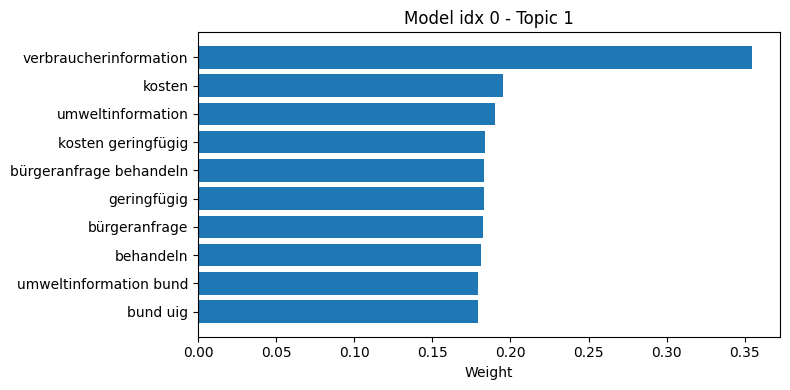

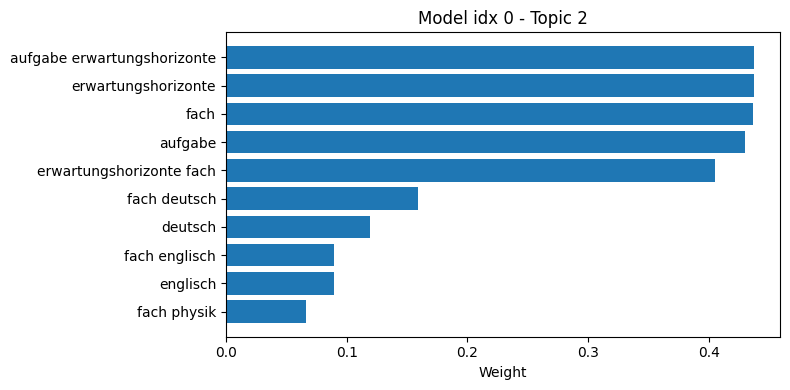

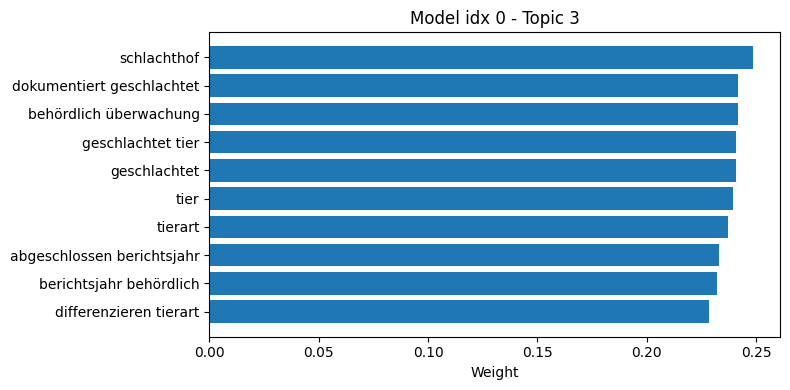

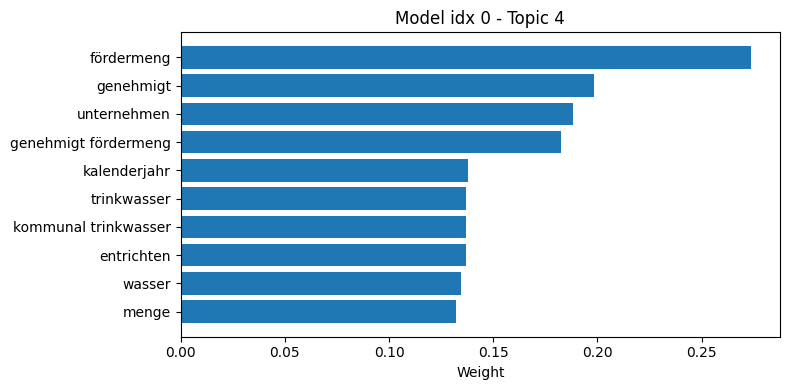

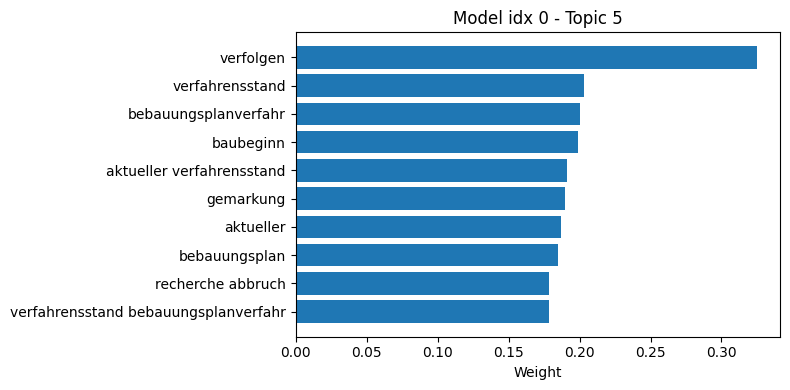

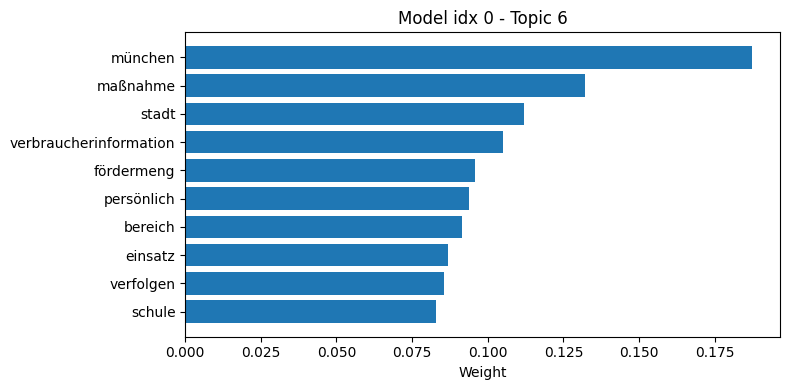

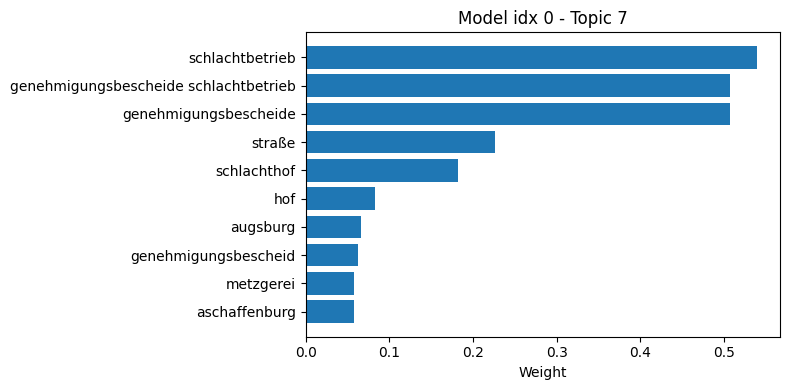

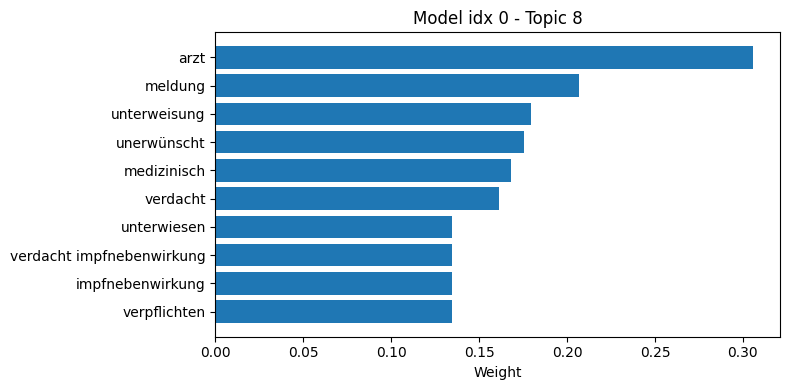

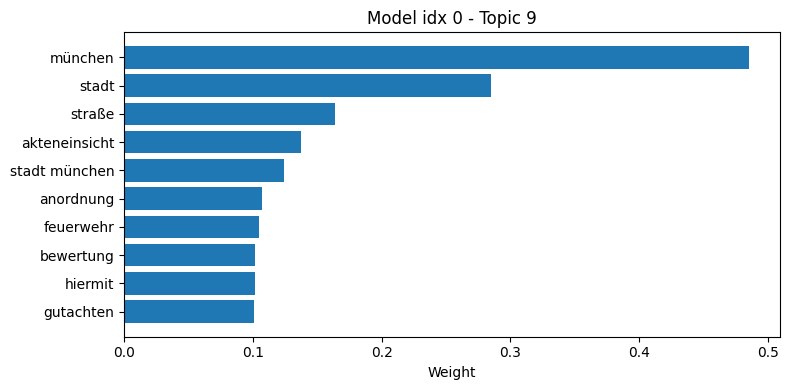

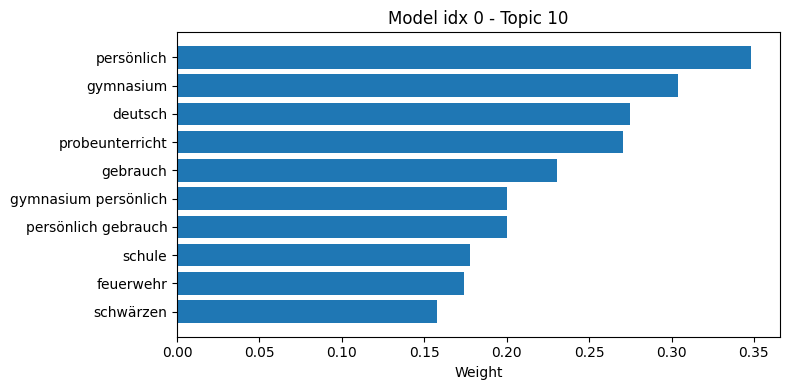


=== Model idx 2 | 10 Topics | Score: 0.5800 ===


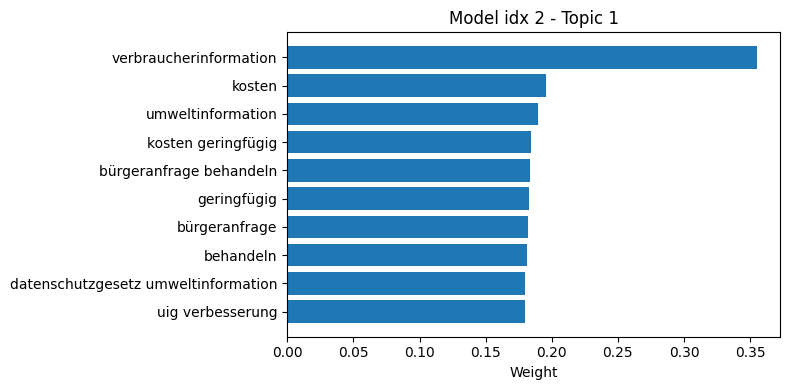

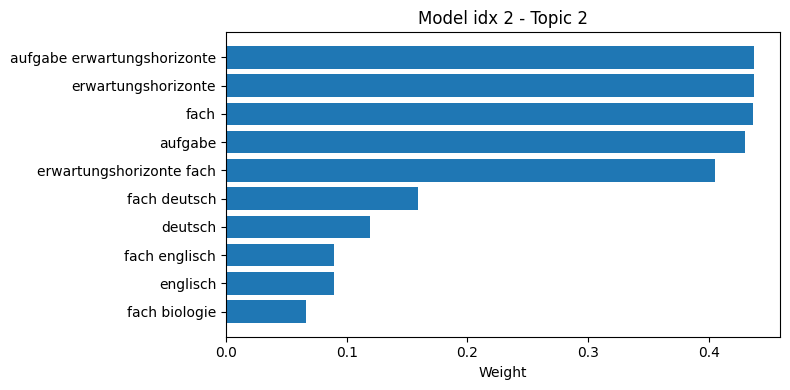

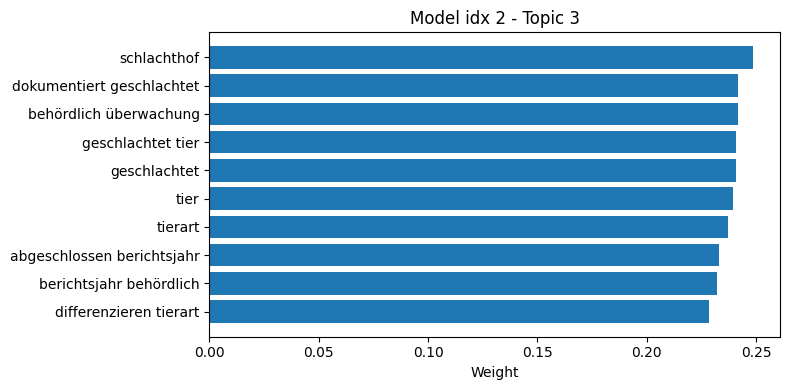

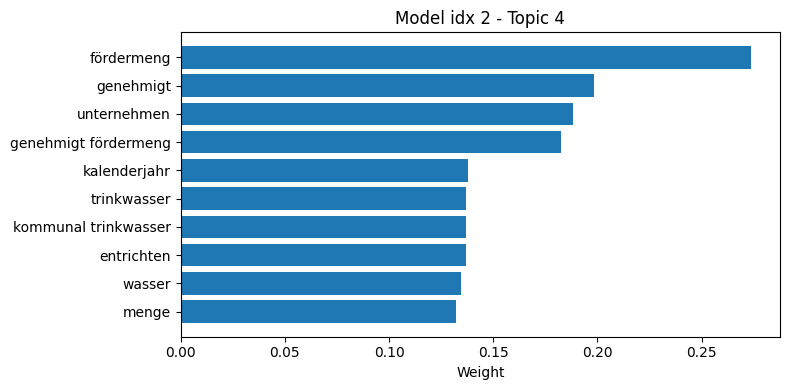

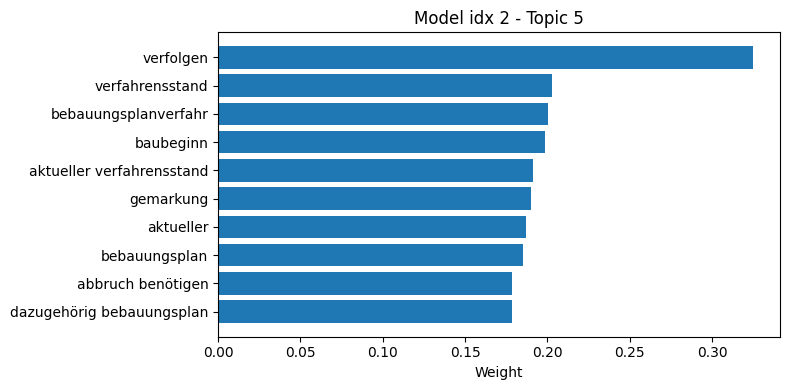

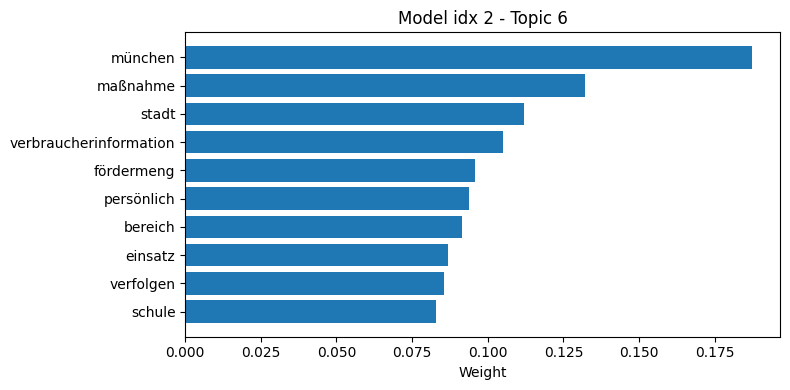

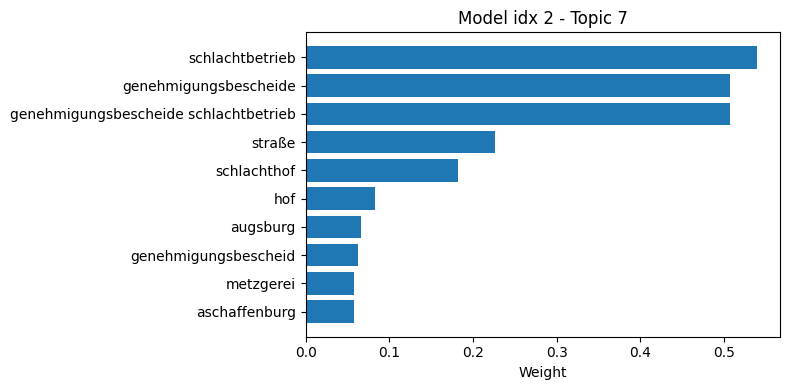

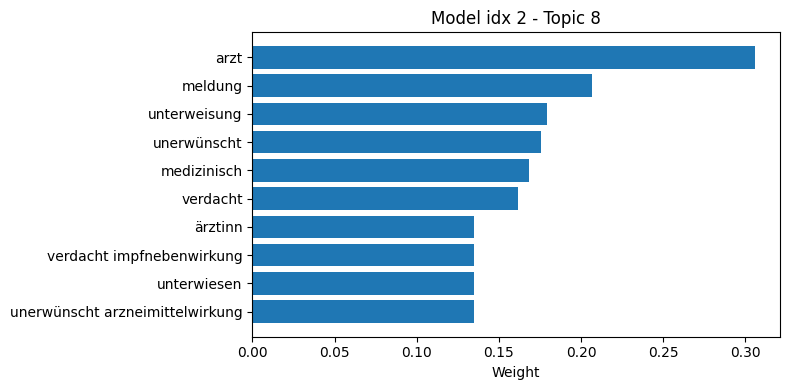

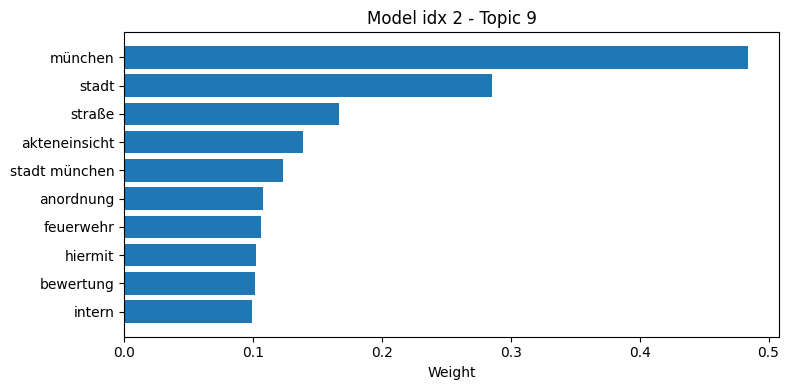

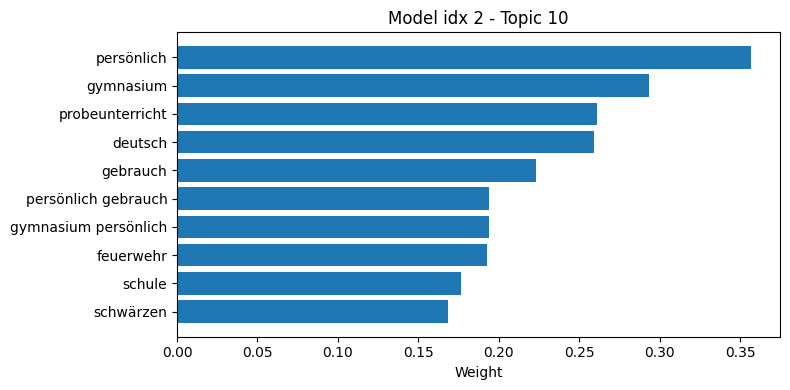


=== Model idx 1 | 10 Topics | Score: 0.5800 ===


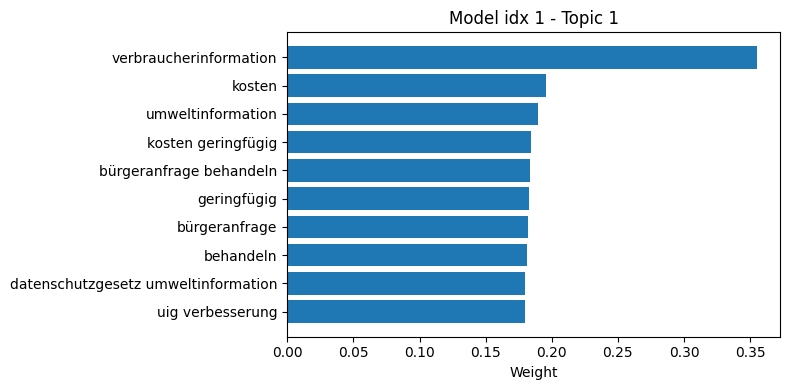

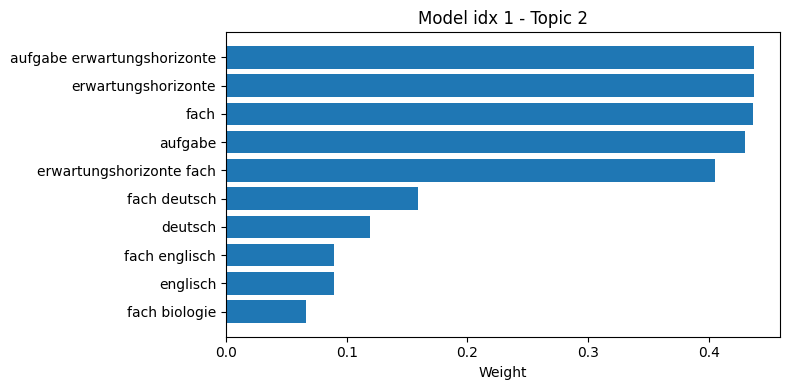

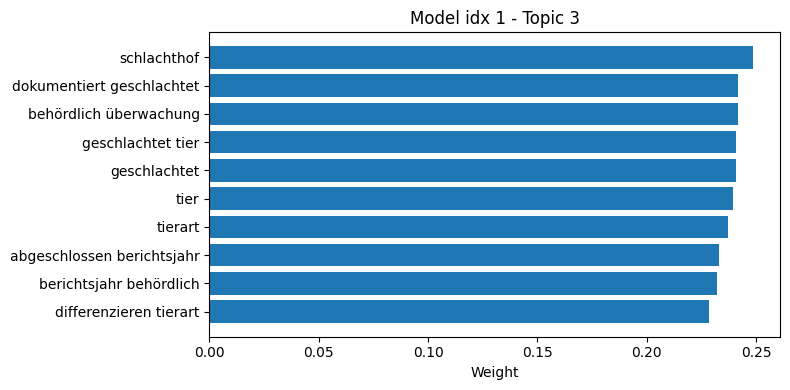

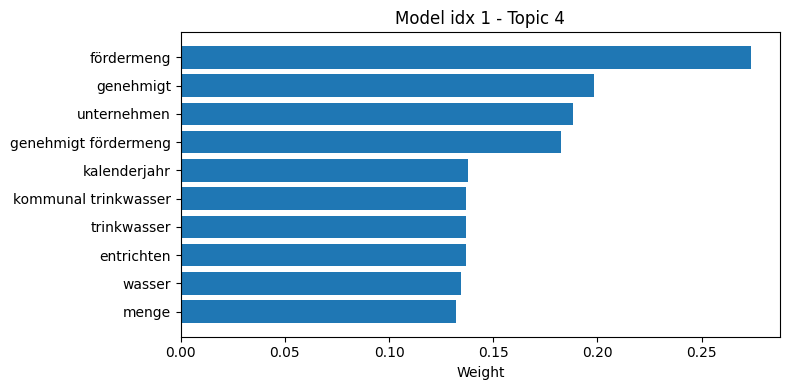

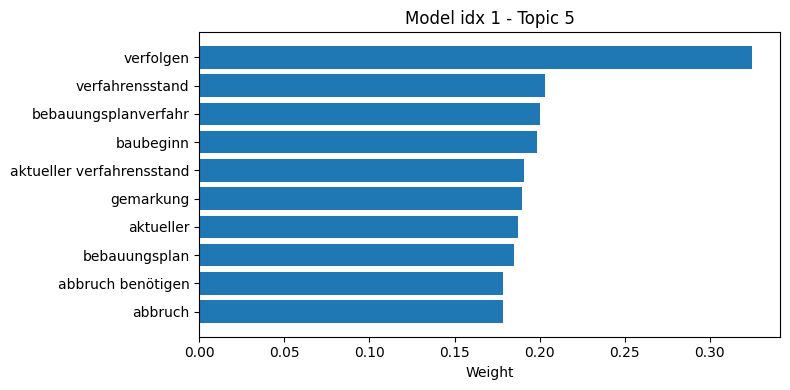

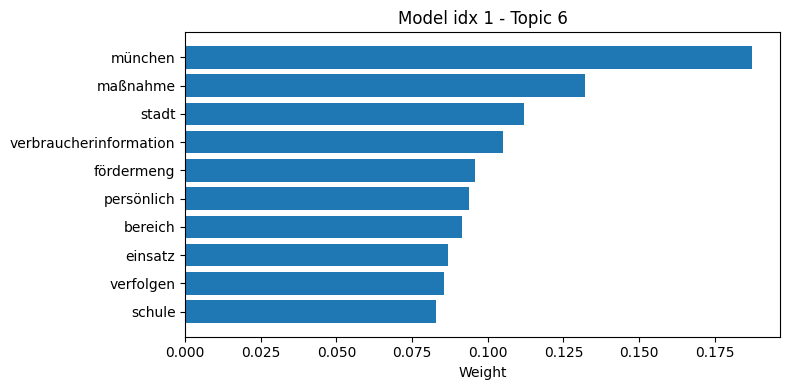

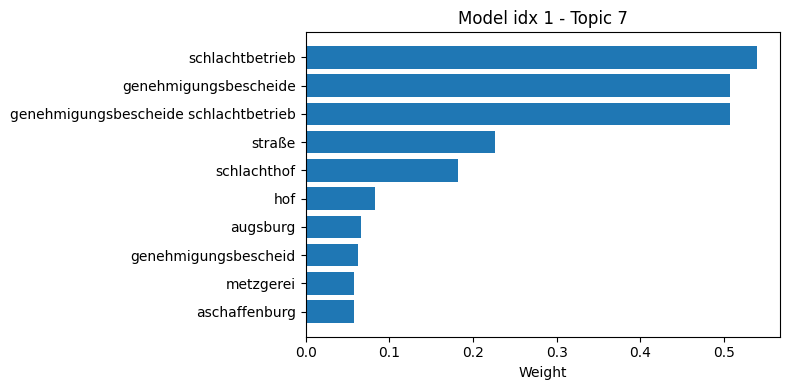

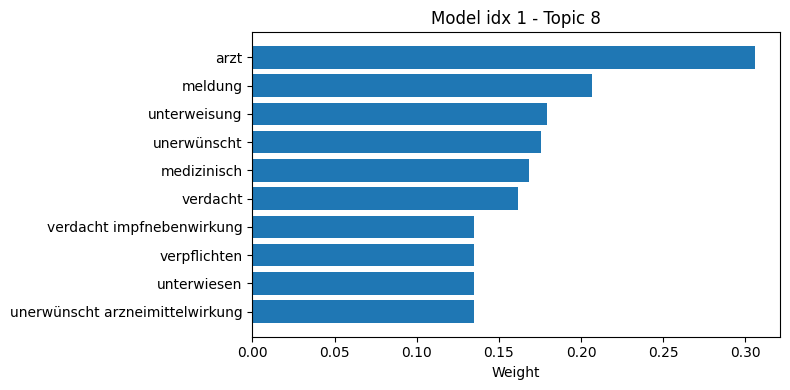

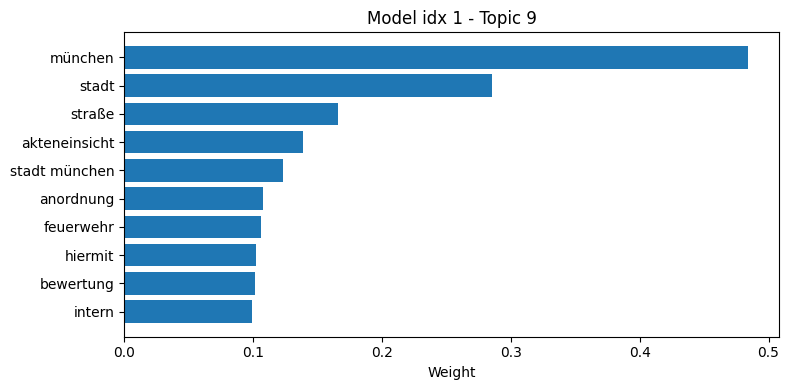

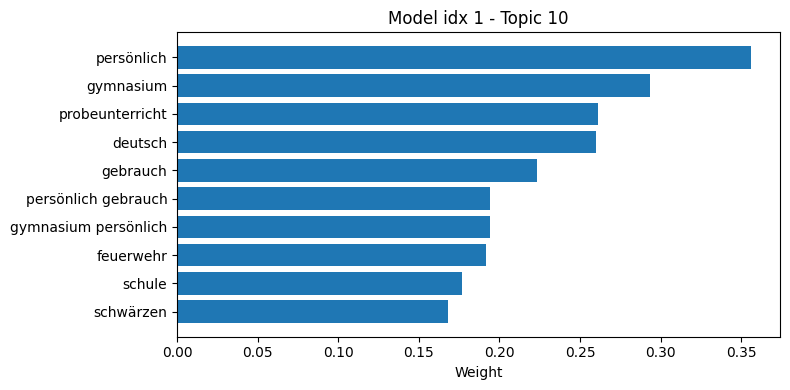


=== Model idx 7 | 30 Topics | Score: 0.5021 ===


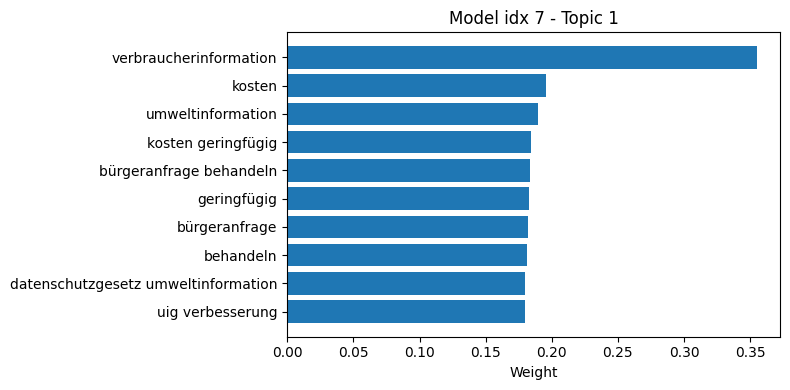

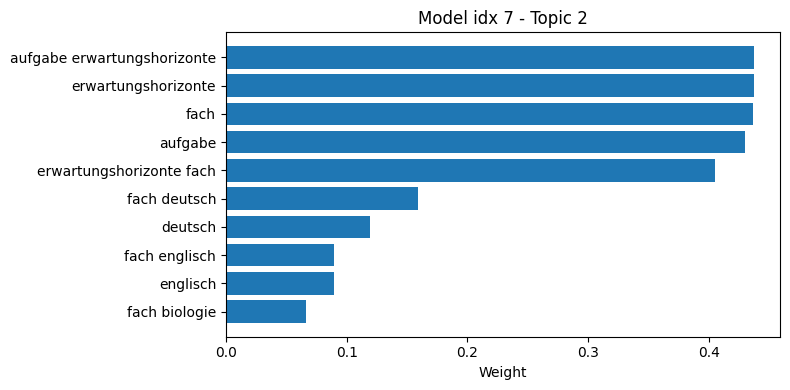

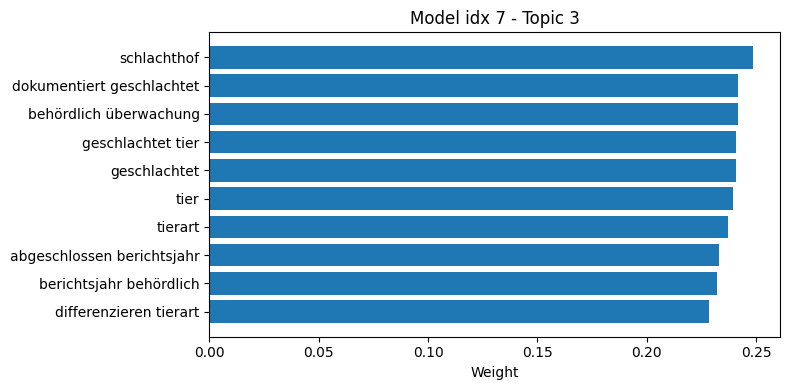

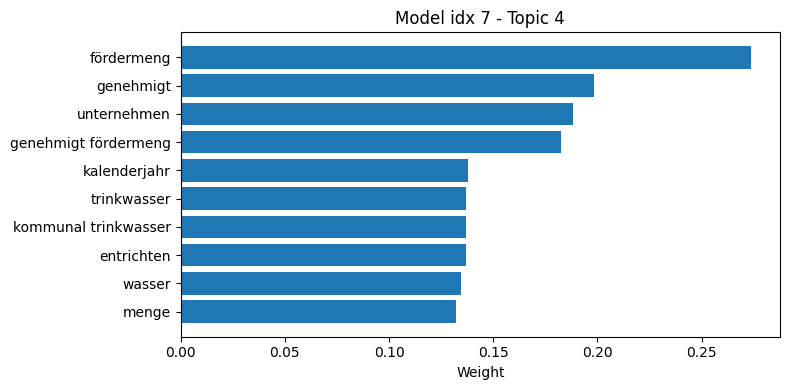

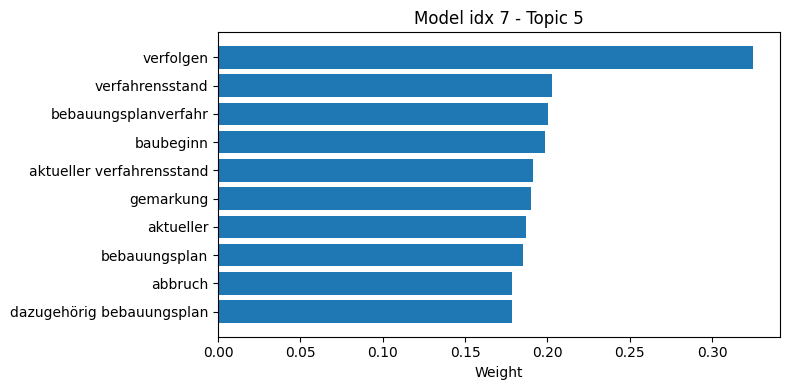

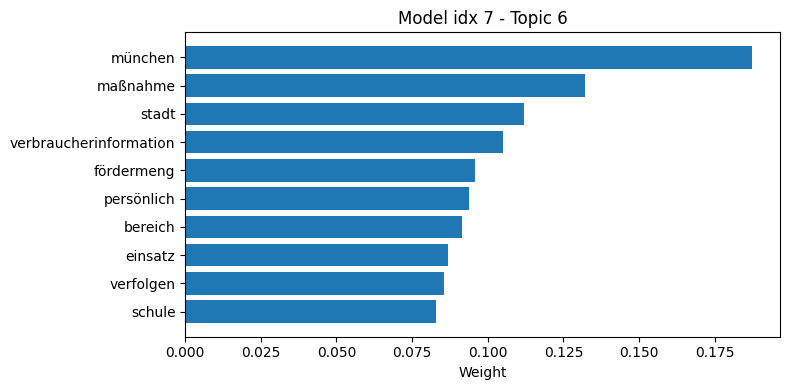

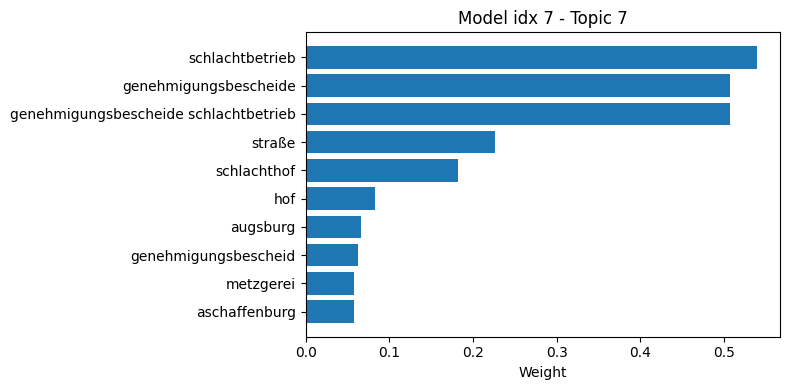

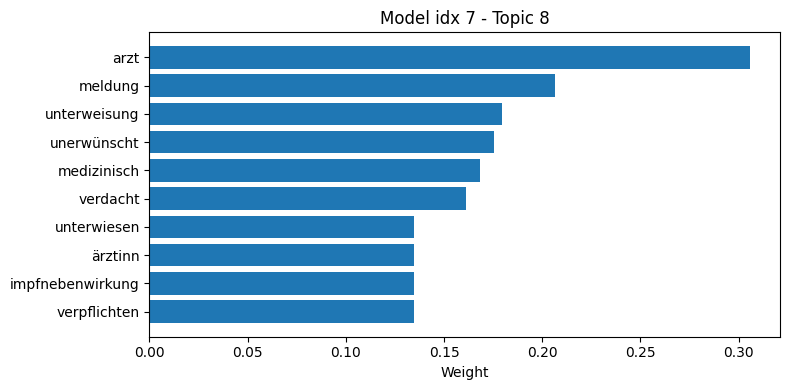

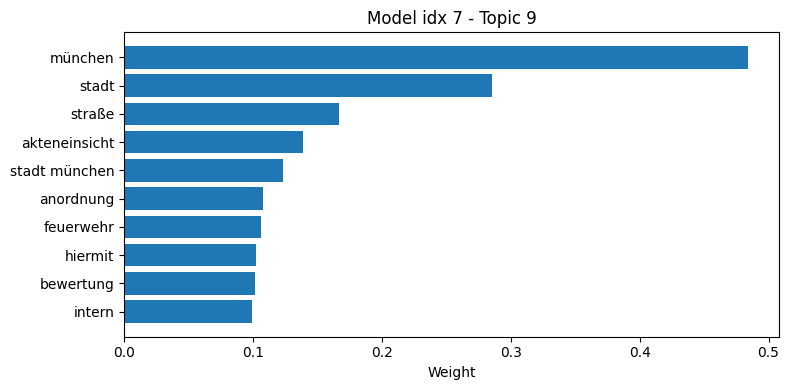

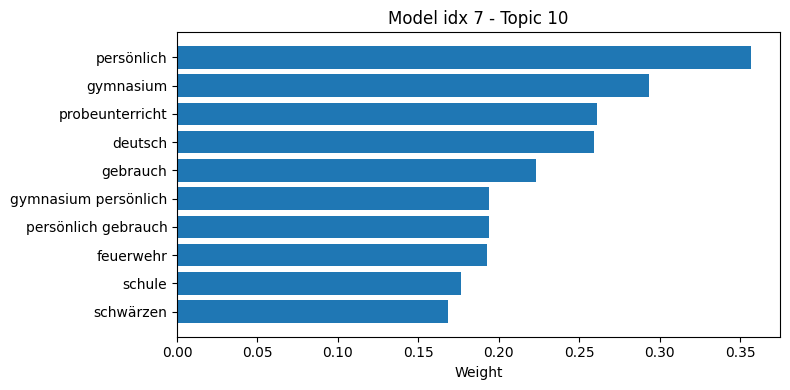

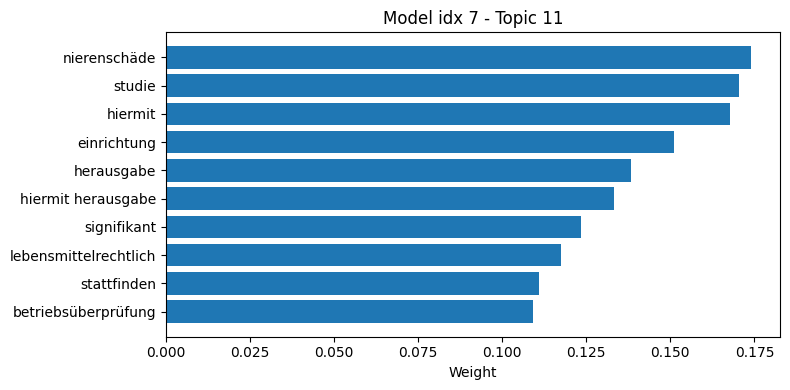

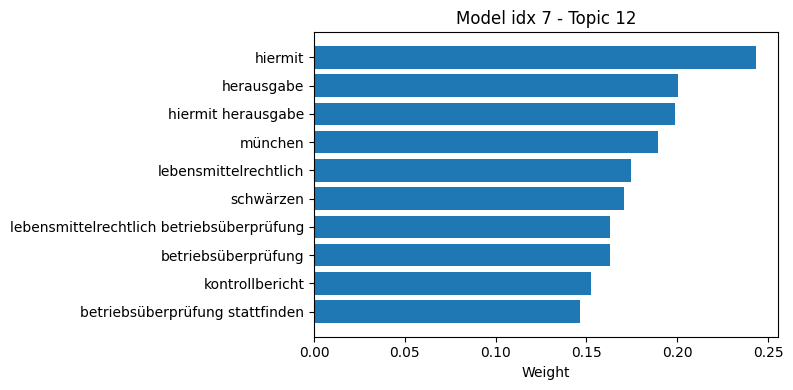

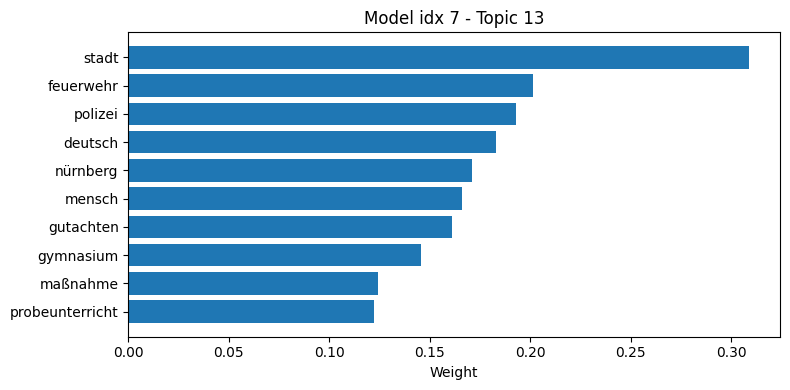

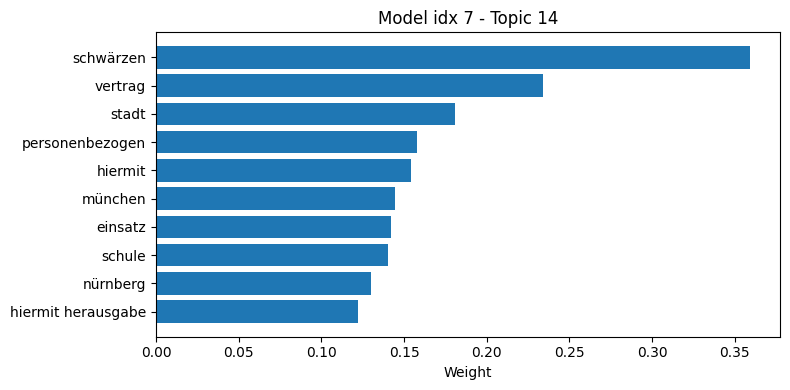

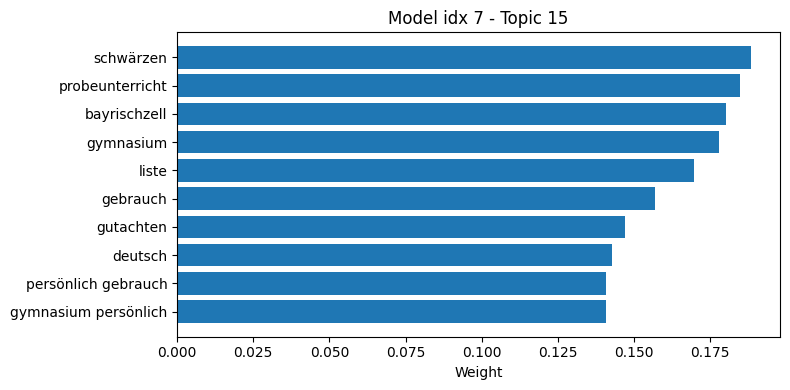

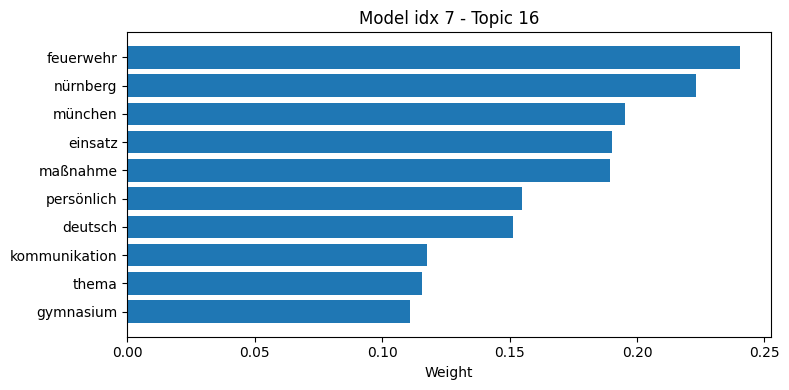

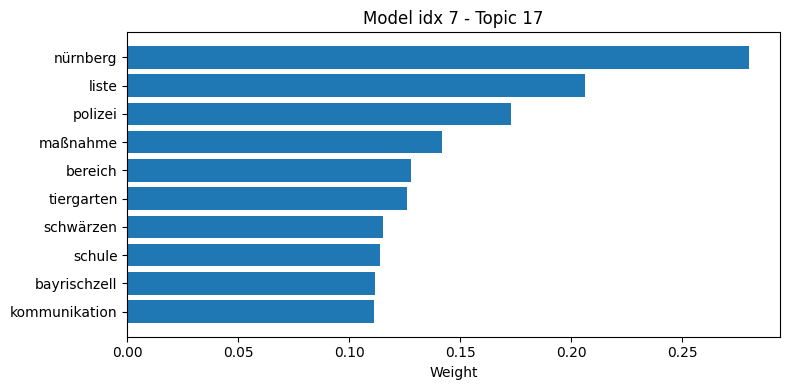

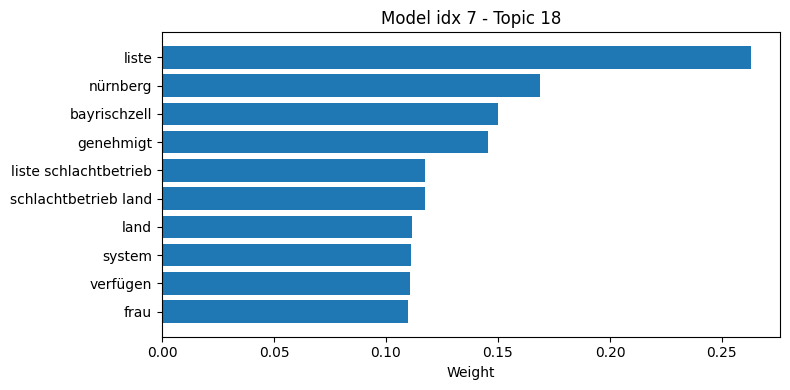

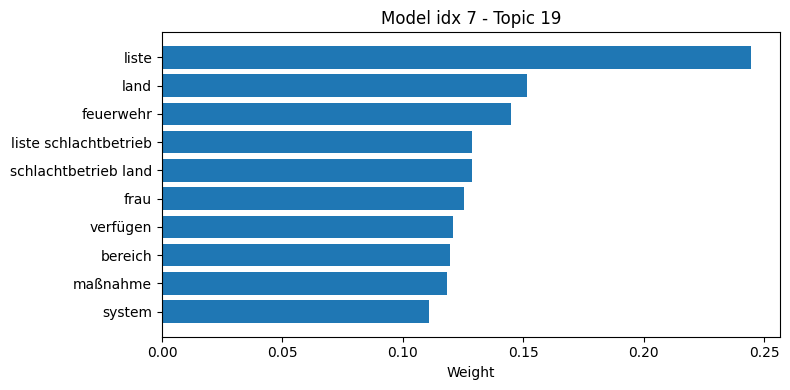

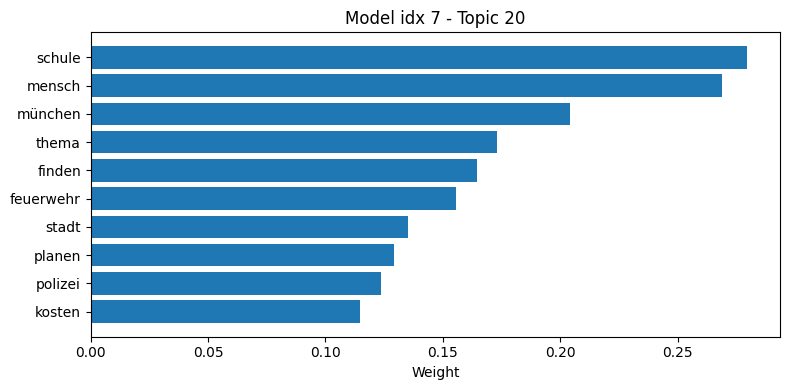

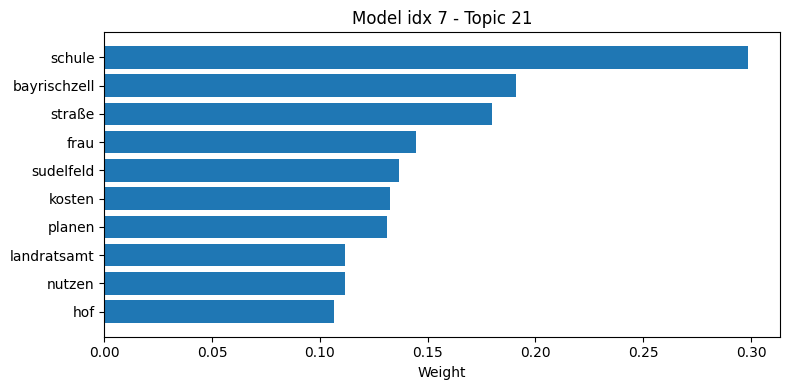

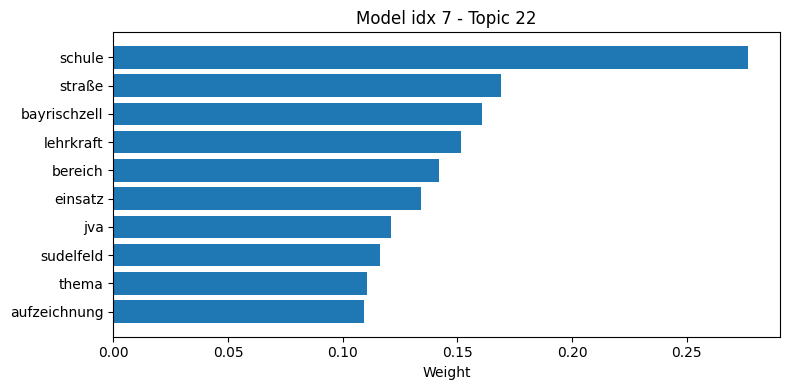

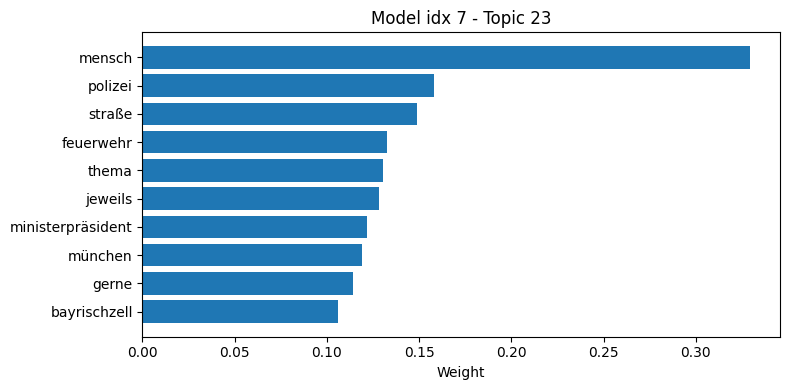

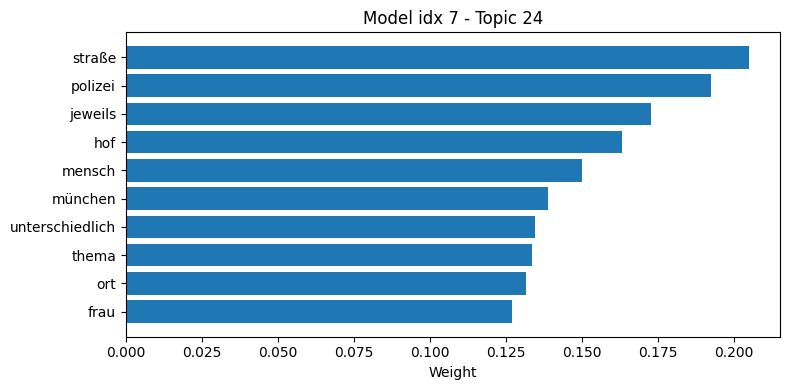

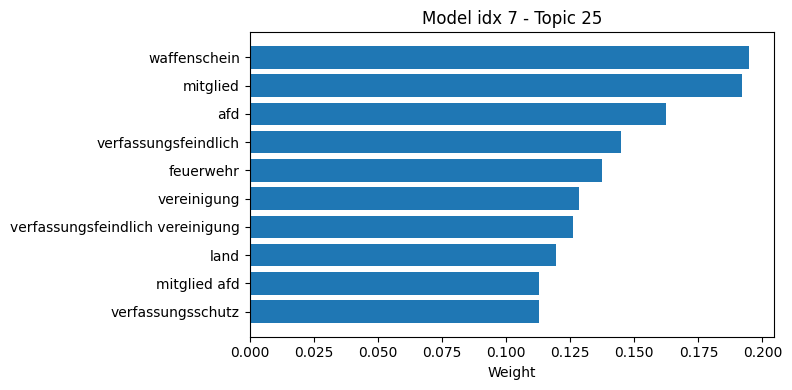

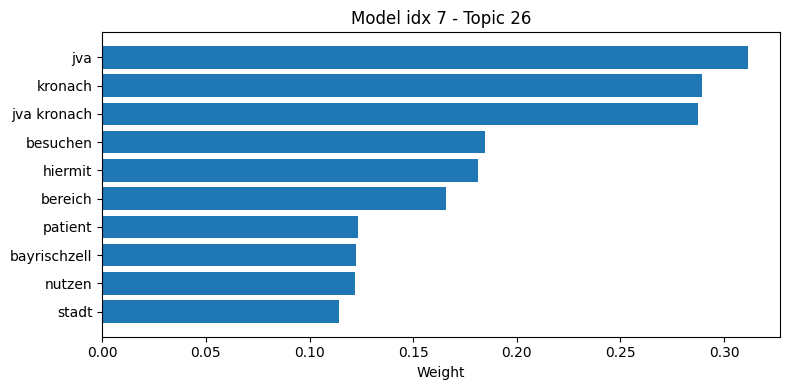

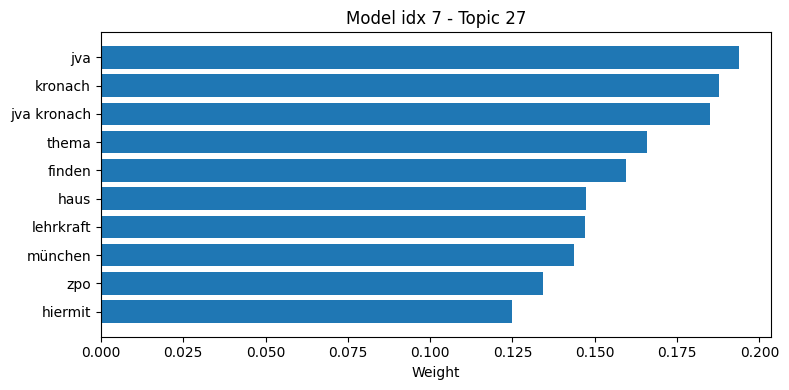

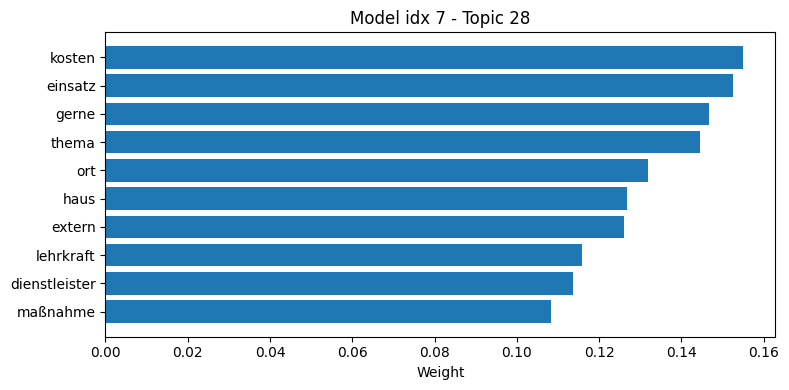

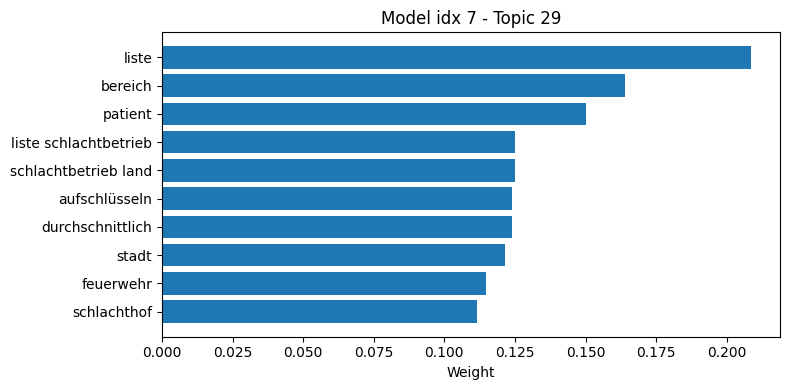

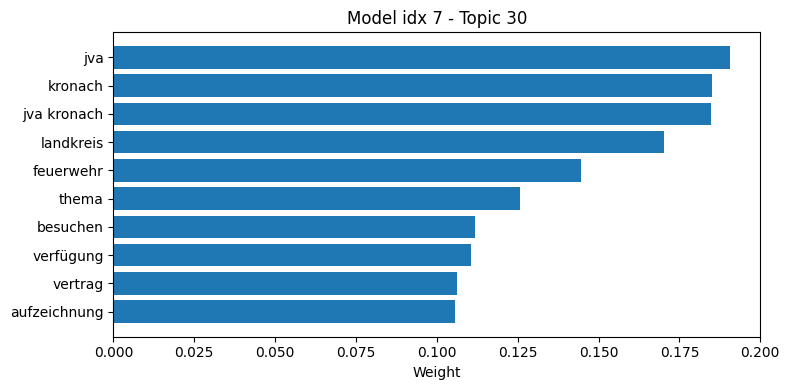


=== Model idx 8 | 30 Topics | Score: 0.4936 ===


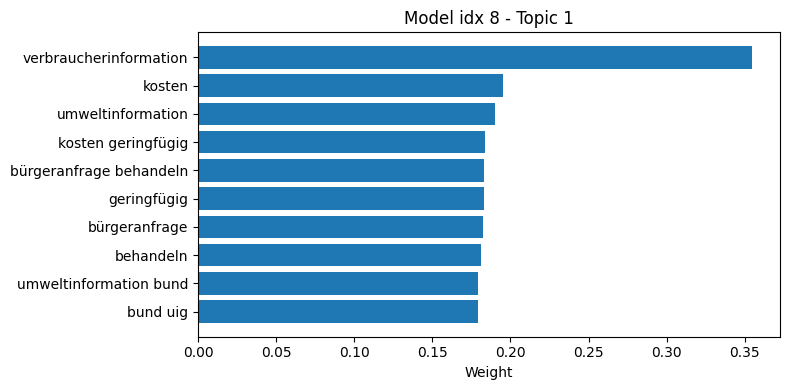

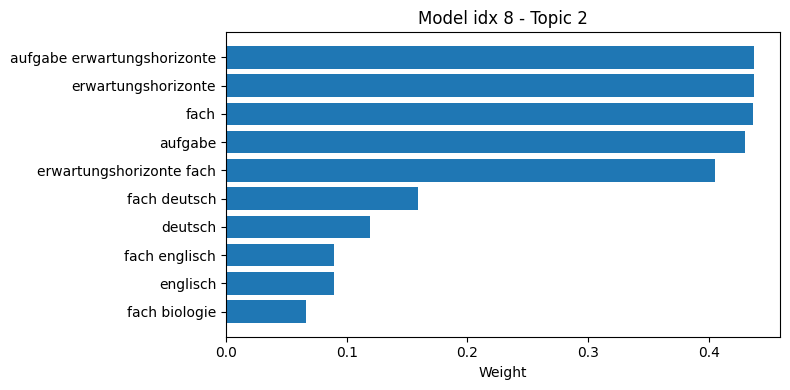

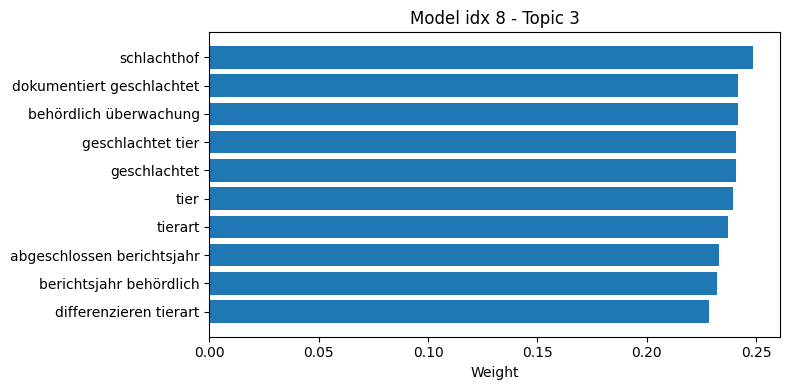

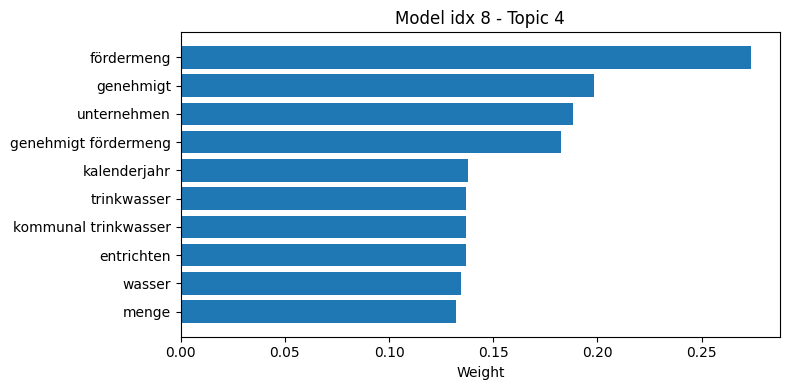

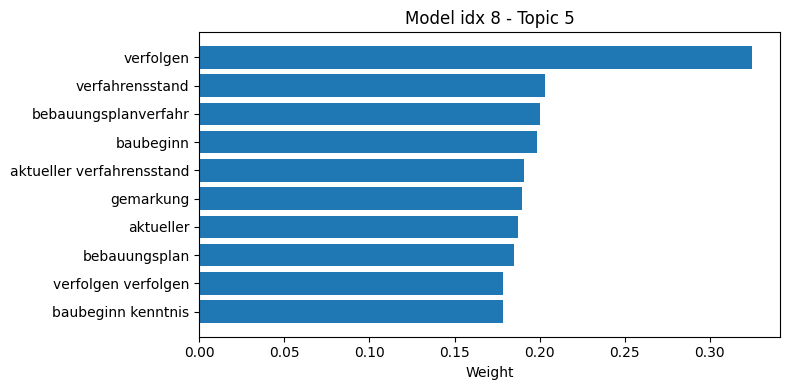

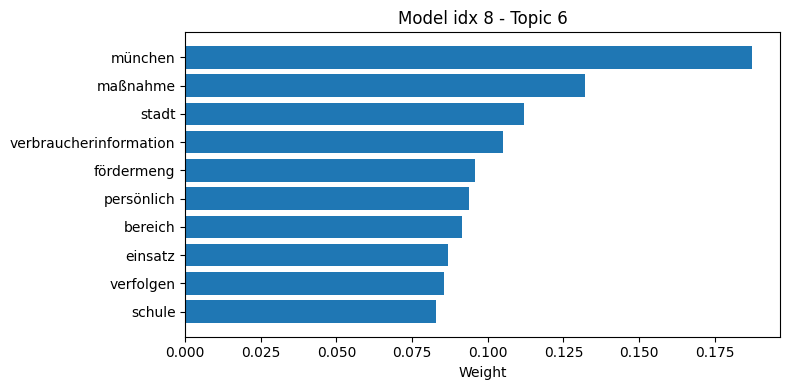

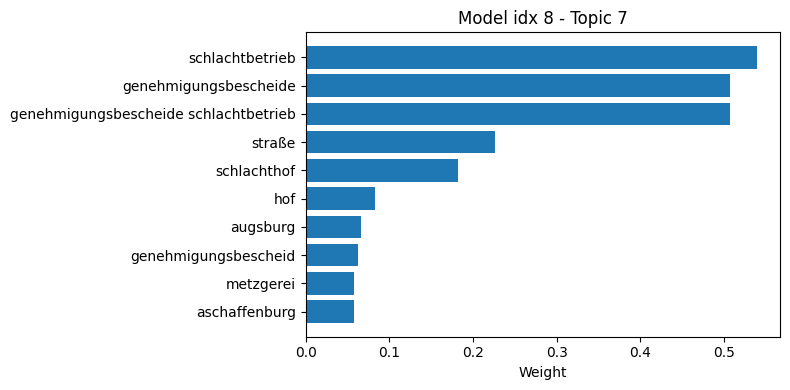

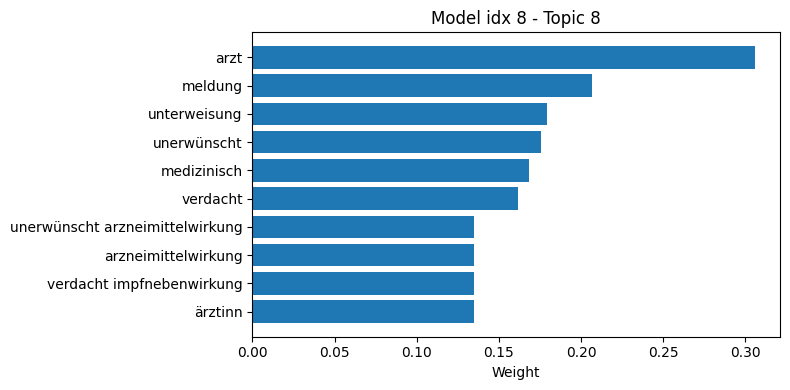

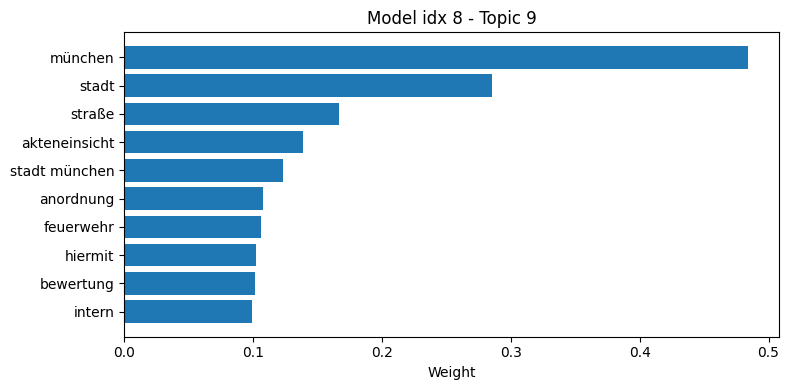

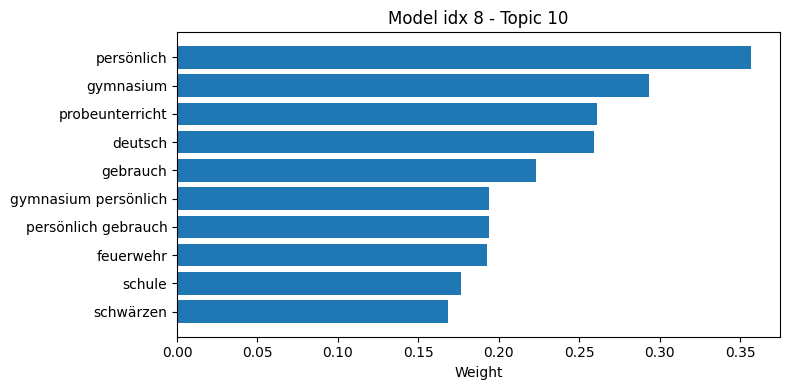

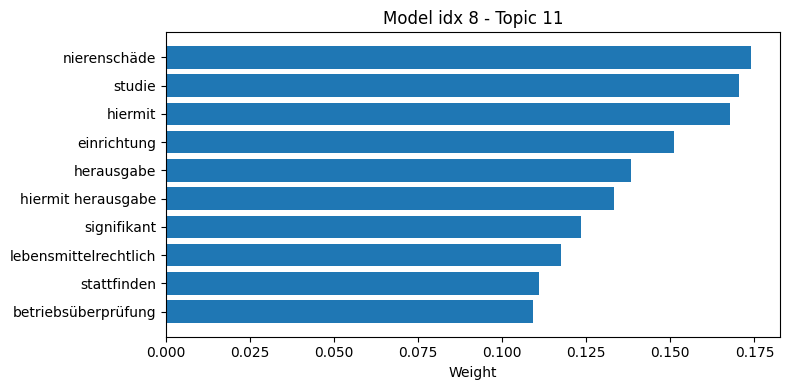

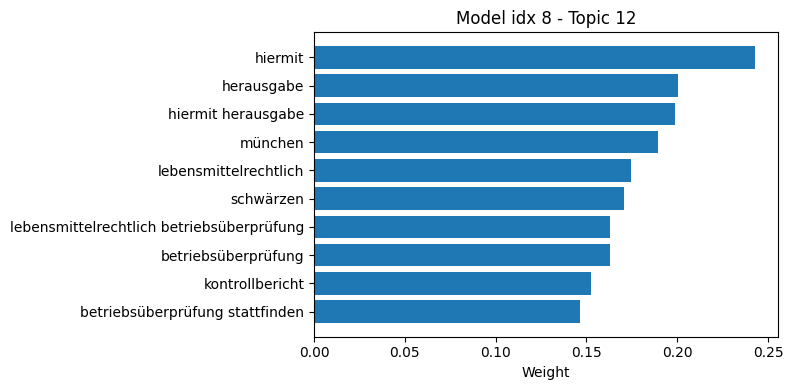

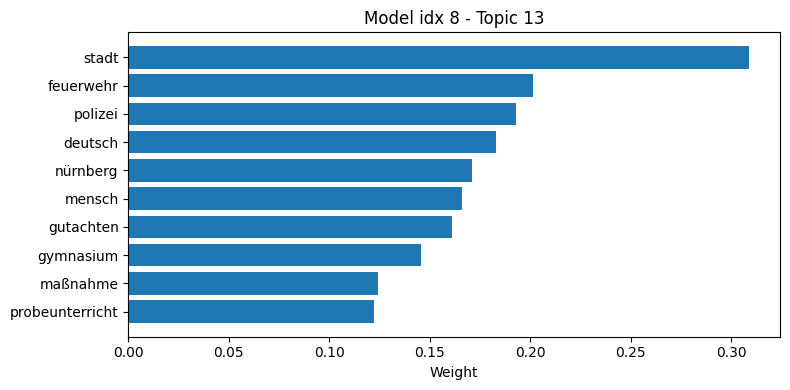

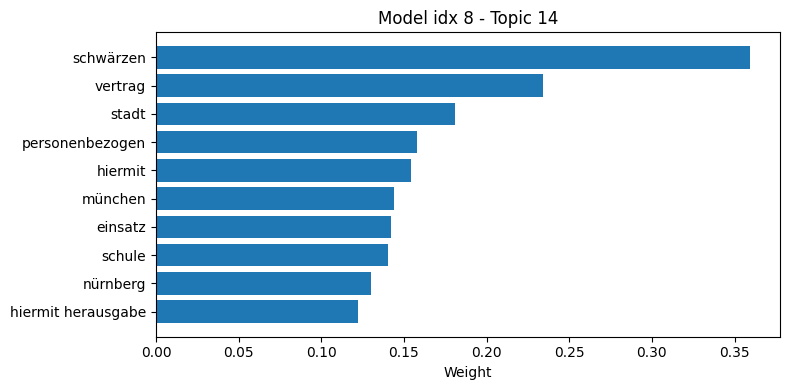

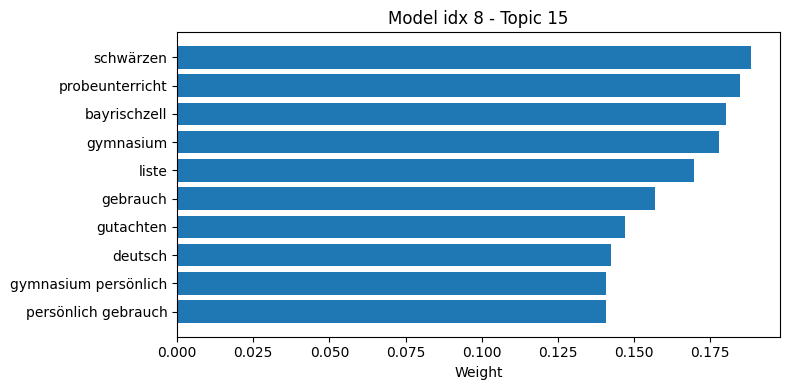

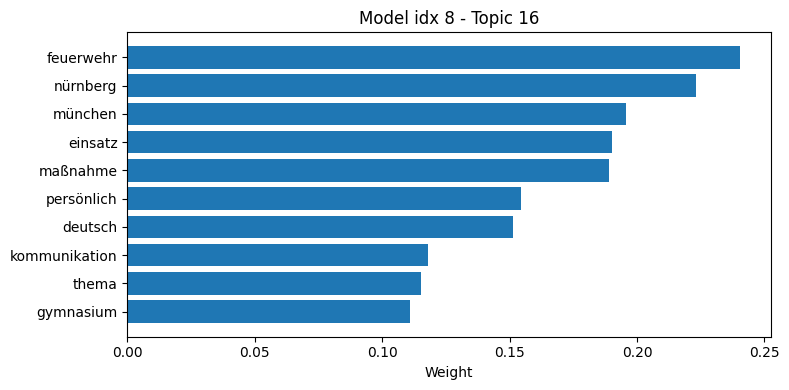

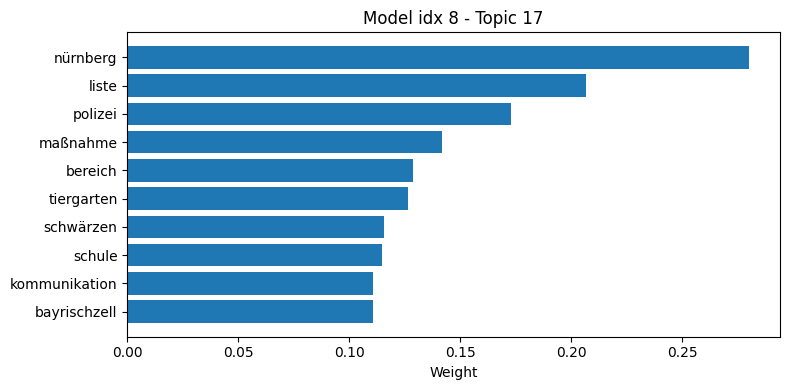

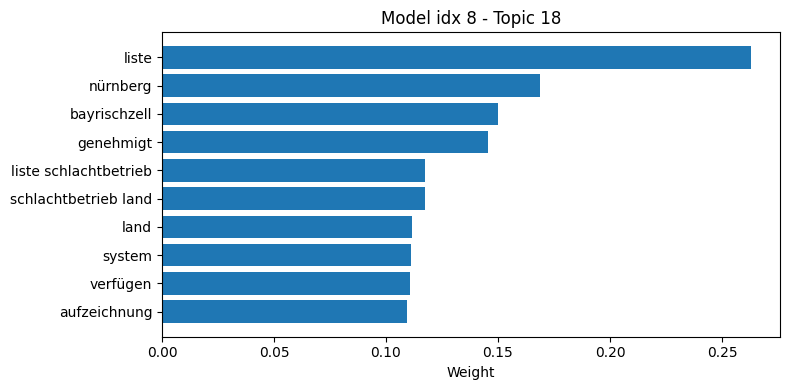

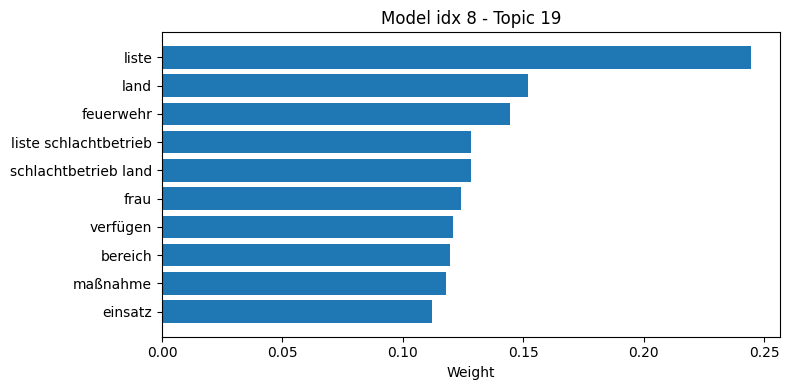

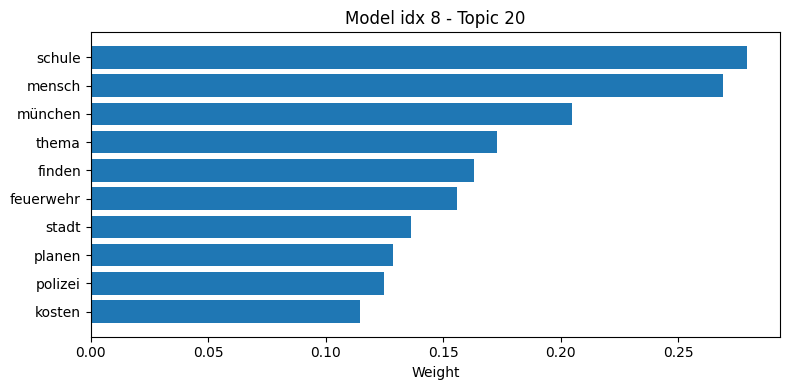

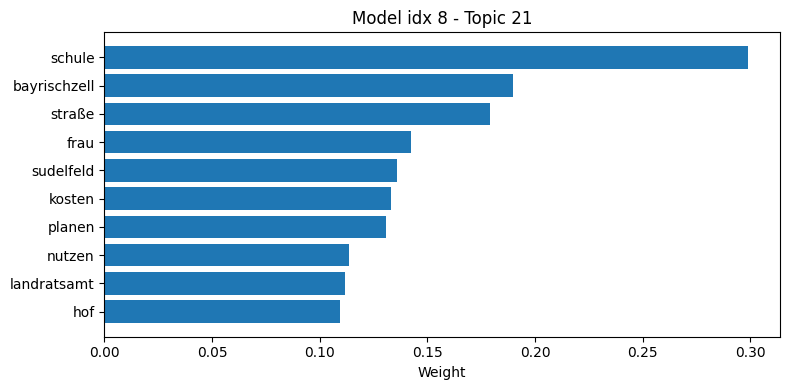

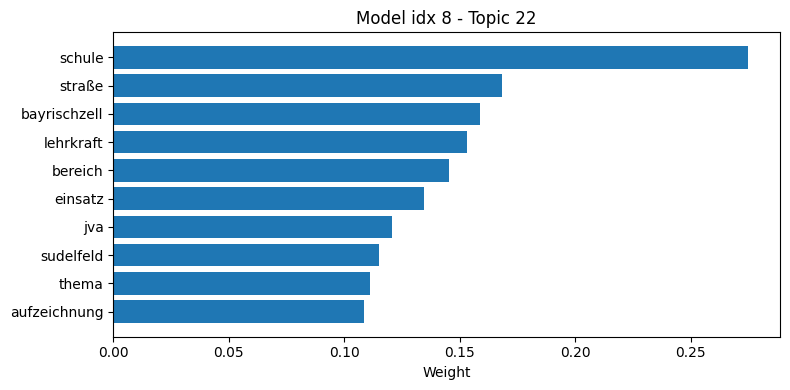

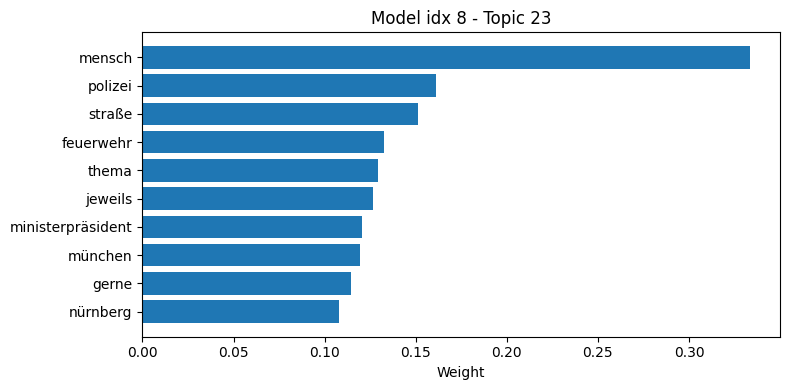

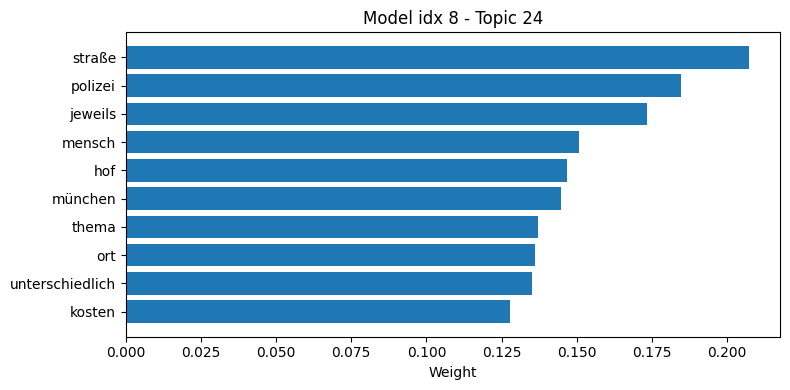

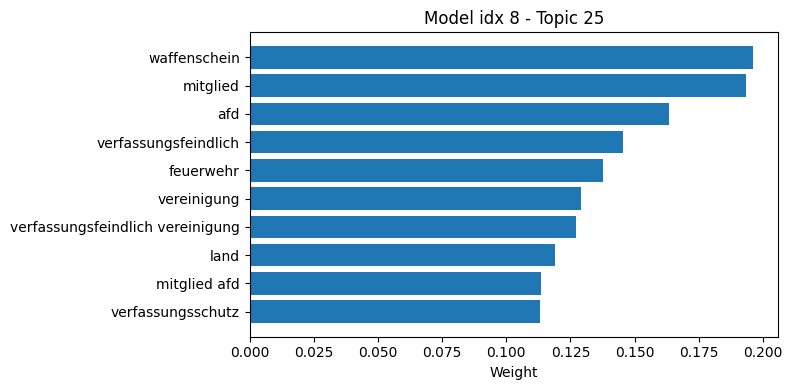

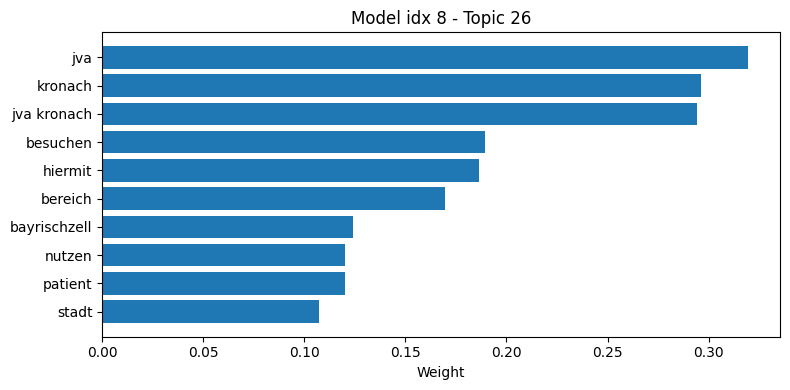

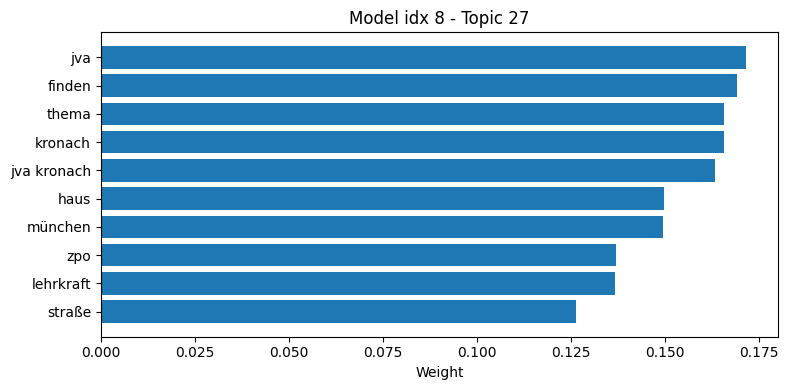

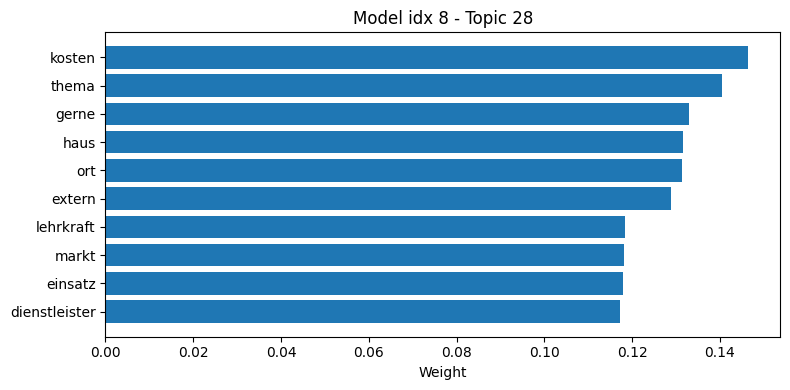

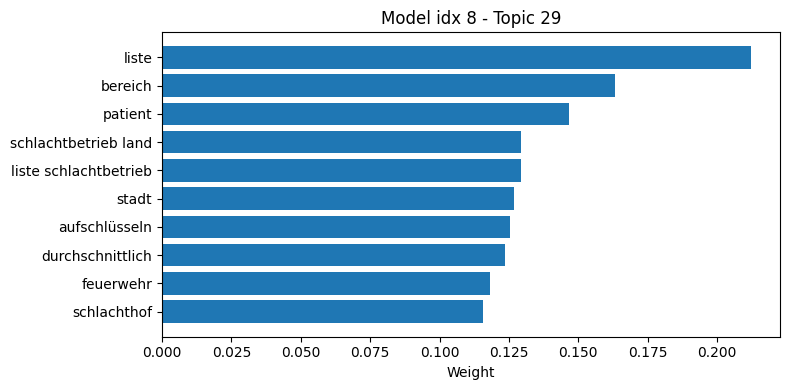

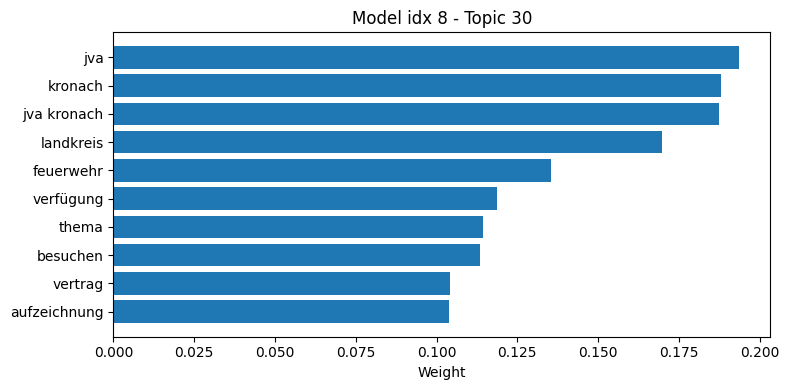

In [99]:
### Topic Visualization of the Selected Model
# Displays the keyword distribution of a selected model.
# Purpose:
# - Validate the qualitative topic structure.
# - Assess the balance of document assignments across topics.
# - Identify dominant, underrepresented, or empty topics.

plot_topic_words(
    lsa_tuning_interpreted_by_lang["de"].iloc[:5]
)

In [77]:
### Topic Size Comparison of Top Models (Table)
# Displays the number of documents assigned to each topic
# for all candidate models.
# Purpose:
# - Assess the balance of topic distributions.
# - Identify dominant or underrepresented topics.
# - Detect empty or nearly empty topics.
# - Support qualitative model selection.
    
display(compare_topic_sizes(
    lsa_tuning_interpreted_by_lang["en"],
    method="lsa",
    title="=== LSA Topic-Größen (EN) ==="
))

=== LSA Topic-Größen (EN) ===


,Topic,Docs (Model 7),Docs (Model 8),Docs (Model 6),Docs (Model 3),Docs (Model 4),Docs (Model 5),Docs (Model 2),Docs (Model 1),Docs (Model 0)
0,0,382,383,391,447,450,450,595,595,598
1,1,37,37,38,43,44,44,53,54,58
2,2,37,37,37,39,39,39,39,39,39
3,3,35,35,35,34,35,35,35,35,36
4,4,32,32,32,31,32,32,36,36,36
5,5,19,19,19,19,19,19,40,40,38
6,6,15,15,15,15,15,15,17,17,16
7,7,27,27,27,28,29,29,48,48,47
8,8,35,35,34,44,44,44,54,54,55
9,9,42,42,42,66,64,64,82,81,76


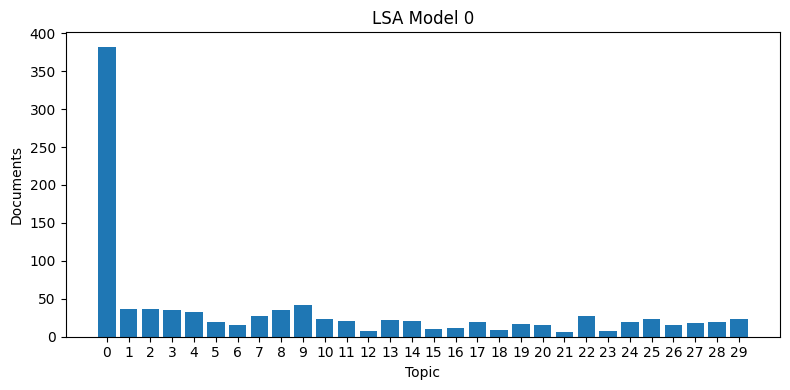

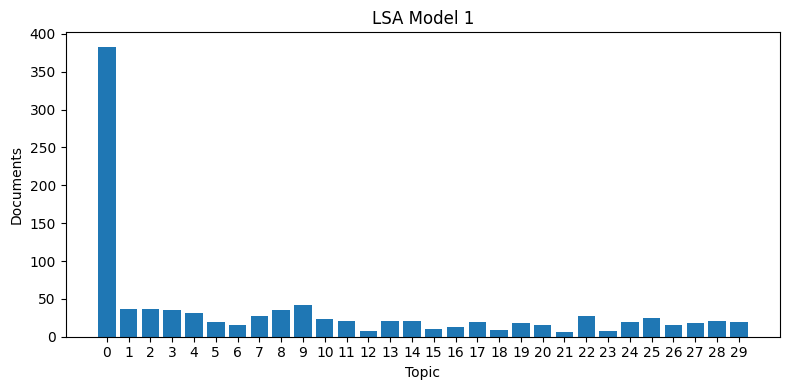

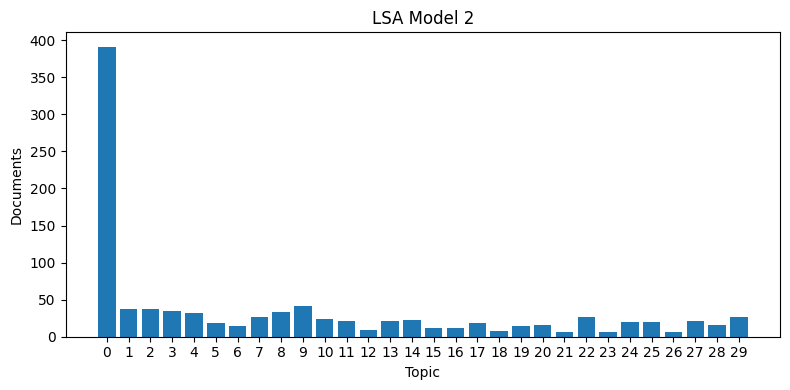

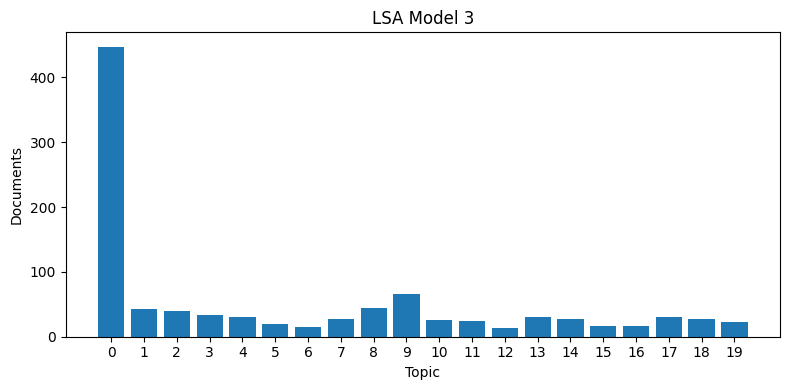

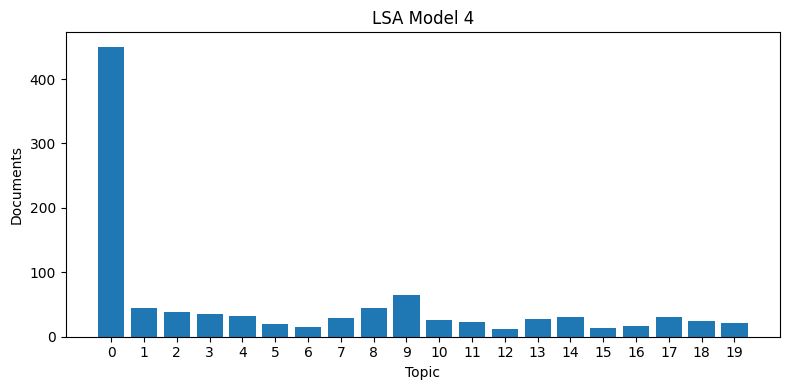

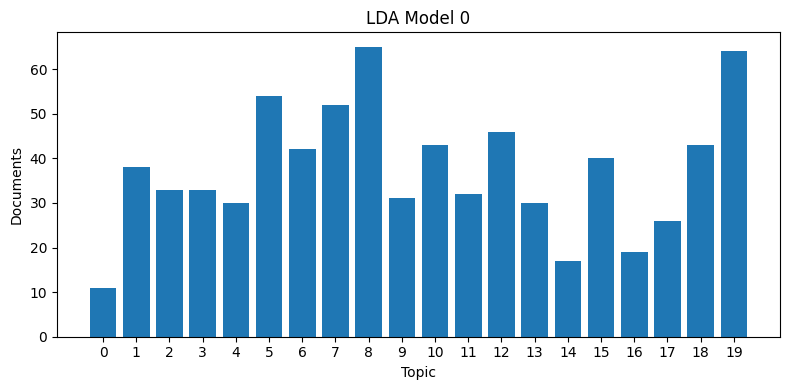

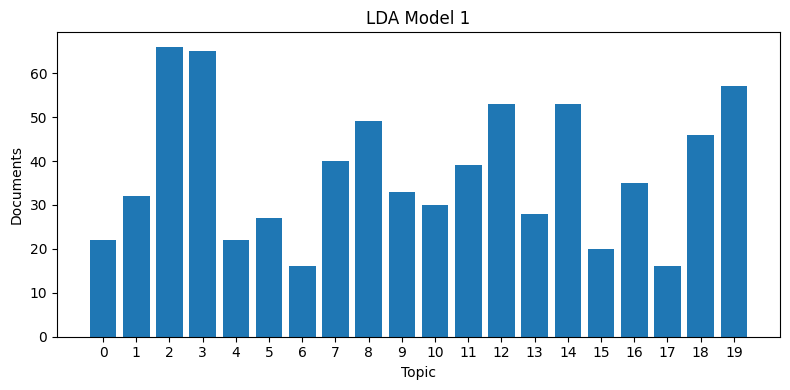

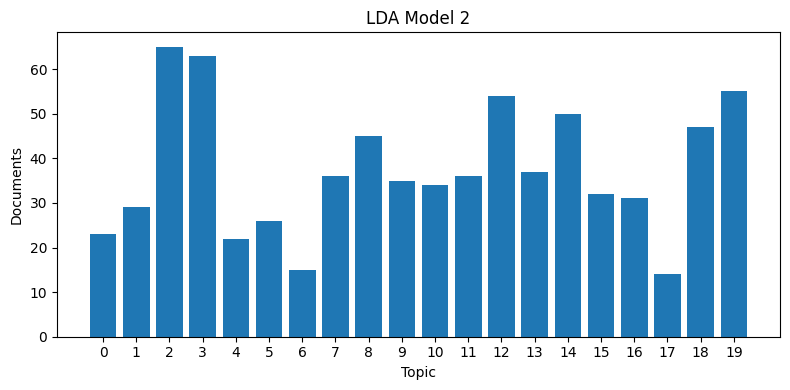

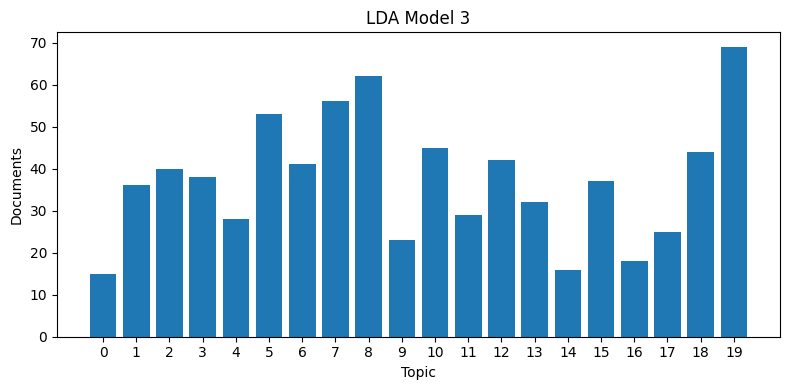

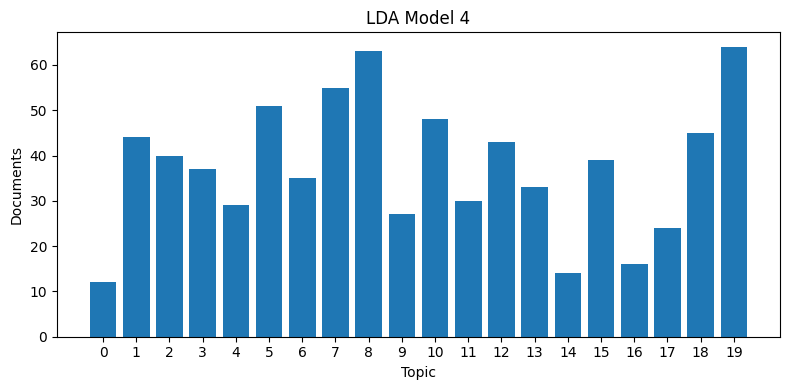

In [100]:
### Topic Size Comparison of Top X or Selected Models (Visual)

for i in range(5):
    row = lsa_tuning_interpreted_by_lang["en"].iloc[i]
        
    plot_topic_sizes(
        doc_topic_matrix=row["doc_topic_matrix"],
        method="lsa",
        title=f"LSA Model {i}"
    )
    
#plot_topic_sizes(
#    doc_topic_matrix=best_row["doc_topic_matrix"],
#    method="lsa",
#    title="LSA Topic Sizes"
#)

for i in range(5):
    row = lda_tuning_interpreted_by_lang["de"].iloc[i]
        
    plot_topic_sizes(
        doc_topic_matrix=row["doc_topic_matrix"],
        method="lda",
        title=f"LDA Model {i}"
    )
#plot_topic_sizes(
#    doc_topic_matrix=best_row["doc_topic_matrix"],
#    method="lda",
#    title="LDA Topic Sizes"
#)

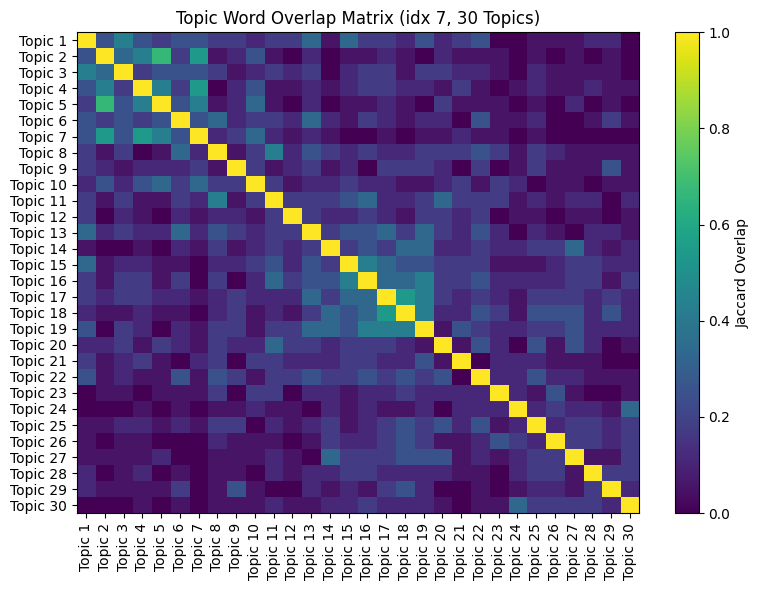

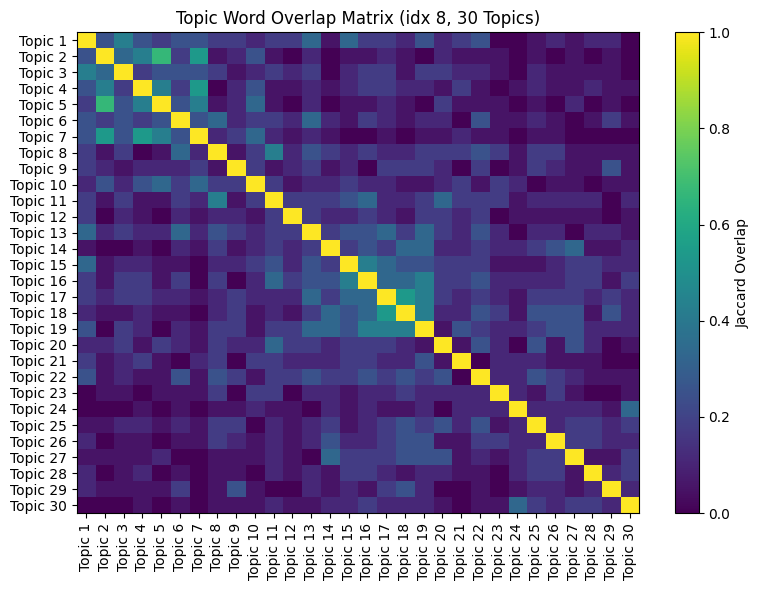

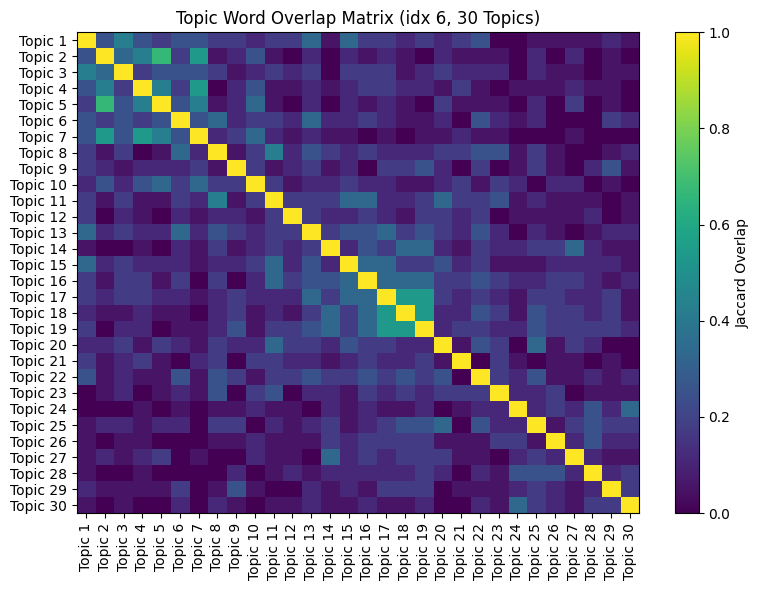

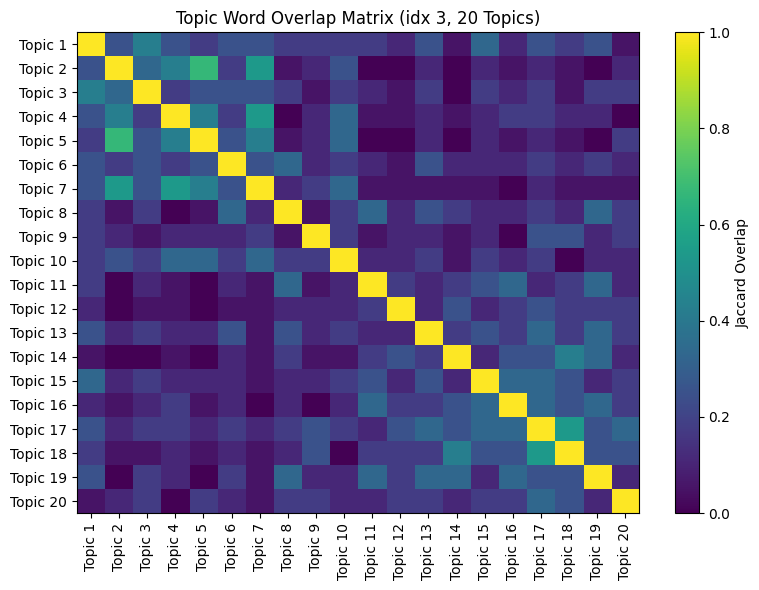

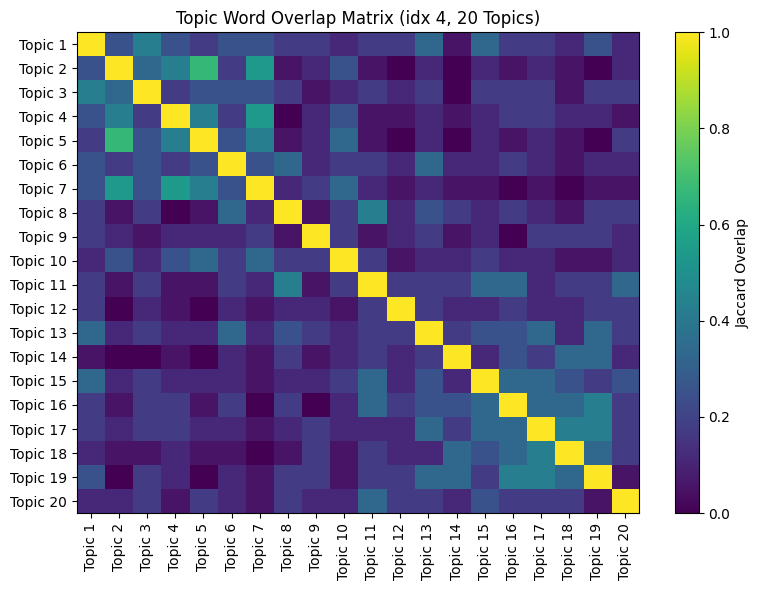

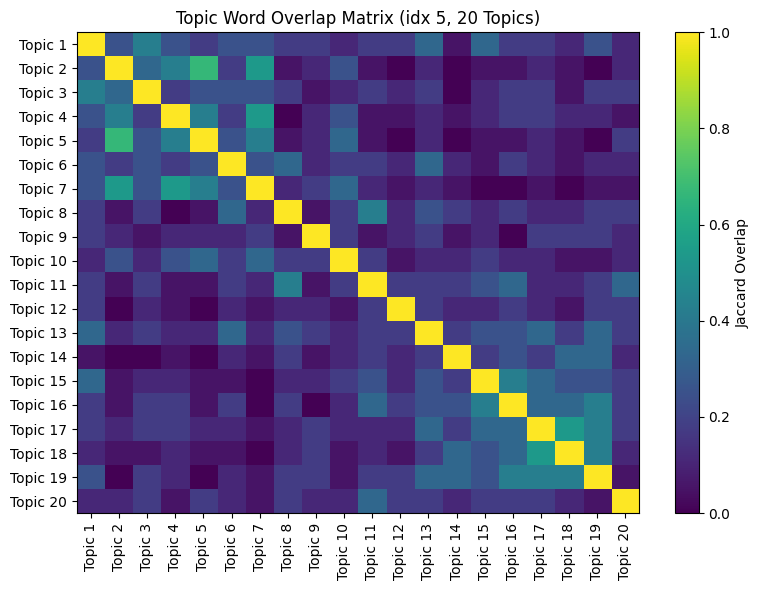

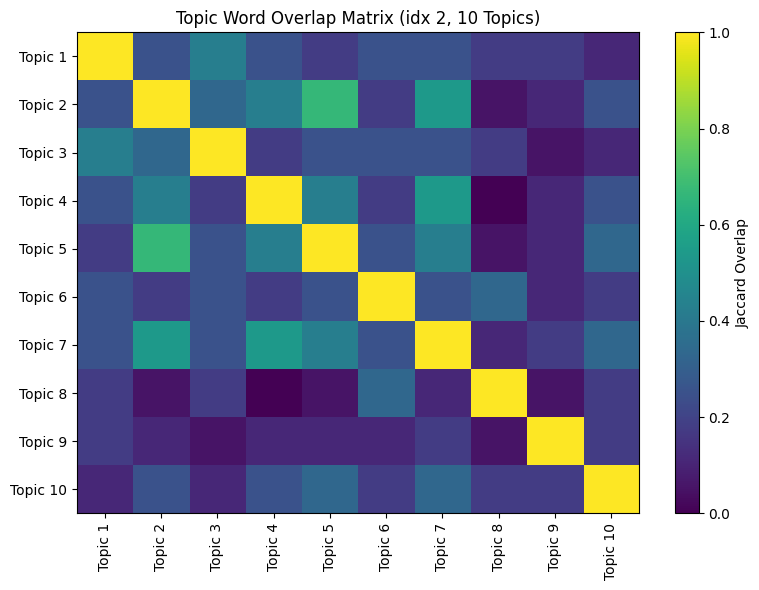

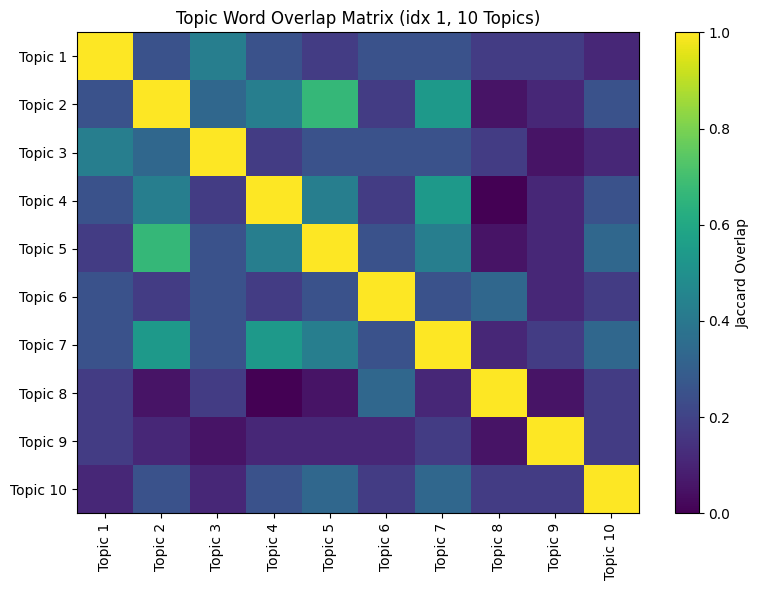

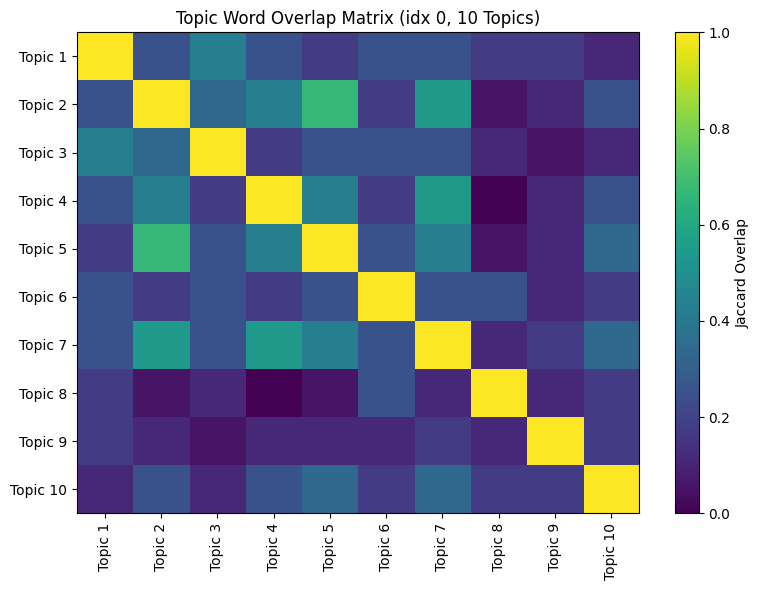

In [110]:
# Displays the overlap of top keywords between topics.
# Purpose:
# - Identify redundant or highly similar topics.
# - Assess whether the number of topics is too high.
# - Evaluate the degree of topic separation.

plot_topic_overlap_matrix(
    lsa_tuning_interpreted_by_lang["en"]
)

In [111]:
############
# FINAL TOPIC + SENTIMENT PIPELINE
# Separate Vector Spaces:
# - Topic Modeling: captures semantic structure of documents
# - Sentiment Analysis: captures emotional polarity independently
############

# 1. Manually Select Final Models
# Select best-performing configurations based on prior evaluation.
# Each selection defines:
# - modeling approach (LDA or LSA)
# - chosen parameter configuration (row)
# - corresponding vector spaces for topic and sentiment analysis
selected_models = {

    "de": {
        "method": "lda",
        "title": "LDA BoW (de)",

        # Manually selected model (not necessarily top-ranked)
        "row": lda_tuning_interpreted_by_lang["de"].iloc[0],

        # Use Bag-of-Words representation for both tasks
        "vector_topic": vectors_topic["bow_by_lang"]["de"],
        "vector_sentiment": vectors_sentiment["bow_by_lang"]["de"],
    },

    "en": {
        "method": "lsa",
        "title": "LSA TFIDF (en)",

        # Manually selected model (not necessarily top-ranked)
        "row": lsa_tuning_interpreted_by_lang["en"].iloc[0],

        # Use TF-IDF representation for both tasks
        "vector_topic": vectors_topic["tfidf_by_lang"]["en"],
        "vector_sentiment": vectors_sentiment["tfidf_by_lang"]["en"],
    }
}

# 2. Extract Final Topic Models
# Retrieve model components (topic terms, document-topic matrix, features)
# for the selected configurations
fitted_models = {}

for lang, selection in selected_models.items():
    fitted_models[lang] = get_selected_topic_model(selection)

# 3. Determine Dominant Topic per Document
# For each document:
# - Identify the most relevant (dominant) topic
# - Compute topic strength
doc_topics = {}

for lang, selection in selected_models.items():

    result = get_selected_topic_model(selection)

    doc_topics[lang] = compute_dominant_topics(
        doc_topic_matrix=result["doc_topic_matrix"],
        documents=result["documents"],
        method=selection["method"]
    )

# 4. Sentiment Analysis
# Compute sentiment score and label (positive / neutral / negative)
# for each document, independent of topic modeling
sentiments = {}

for lang, selection in selected_models.items():

    sentiments[lang] = build_sentiment_df(
        selection["vector_sentiment"],
        lang=lang
    )

# 5. Merge Topic + Sentiment
# Combine topic assignments with sentiment results
# to associate each document with both semantic and emotional information
doc_topics_sentiment = {}

for lang in doc_topics.keys():

    doc_topics_sentiment[lang] = merge_topic_sentiment(
        doc_topics[lang],
        sentiments[lang]
    )

# 6. Aggregate Topic + Sentiment Matrix
# Compute aggregated statistics per topic:
# - number of documents
# - average topic strength
# - average sentiment score
# - distribution of sentiment labels
topic_sentiment_summary = {}

for lang, df in doc_topics_sentiment.items():

    topic_sentiment_summary[lang] = build_topic_sentiment_summary(df, lang)


# 7. Display Final Topic + Sentiment Matrices

for lang, summary_df in topic_sentiment_summary.items():

    selection = selected_models[lang]
    topic_terms = selection["row"]["topic_terms"]

    summary_display = summary_df.copy()

    # Top words per topic
    topic_keywords = {
        int(topic_name.split()[-1]) - 1: ", ".join(
            term["word"] for term in terms
        )
        for topic_name, terms in topic_terms.items()
    }

    summary_display["top_words"] = (
        summary_display["dominant_topic"]
        .map(topic_keywords)
    )

    print(f"\n=== Topic + Sentiment Vergleich ({lang}) ===")

    display(
        style_topic_sentiment(
            summary_display,
            f"{selection['title']} - Topic & Sentiment Matrix",
            pos_threshold=0.05,
            neg_threshold=-0.05
        )
    )


=== Topic + Sentiment Vergleich (de) ===


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative,top_words
1,11,0.872066,0.298136,1,10,0,"münchen, kosten, stadt, zusendung, rohr, landeshauptstadt münchen, landeshauptstadt, bezüglich, logistikpark, vollständig"
2,38,0.820834,-0.010474,0,36,2,"gehweg, lehrkraft, unterbringung, bundesland, jeweilig, ministerium, anordnung, stgb, geben, verstoß"
3,33,0.852596,-0.000094,2,30,1,"verfolgen, verfahrensstand, bebauungsplanverfahr, baubeginn, gemarkung, aktueller verfahrensstand, aktueller, bebauungsplan, recherche, dazugehörig bebauungsplan"
4,33,0.939655,0.041958,3,29,1,"unternehmen, standort, markt, oberkotzau, vertrag, fahrzeug, persönlich, korrespondenz, unterhalten, hof"
5,30,0.923980,0.085187,4,26,0,"tier, überwachung, dokumentiert, tierart, geschlachtet tier, geschlachtet, behördlich, behördlich überwachung, dokumentiert geschlachtet, schlachthof"
6,54,0.855426,0.009350,2,50,2,"münchen, waffenschein, thema, mitglied, verfügung, verfassungsfeindlich, afd, konkret, verfassungsschutz, maßnahme"
7,42,0.782261,0.044821,1,41,0,"frau, schule, nutzen, landkreis, dienst, stadt, feuerwehr, jungtier, mensch, einsatz"
8,52,0.819802,0.069658,3,48,1,"aufgabe, erwartungshorizonte, fach, straße, aufgabe erwartungshorizonte, erwartungshorizonte fach, schlachtbetrieb, genehmigungsbescheide schlachtbetrieb, genehmigungsbescheide, schulstraße"
9,65,0.865900,-0.034674,1,62,2,"bevölkerung, warnung, ortsnah, stehen, stadt, system, digital, verfügung, maßnahme, münchen"
10,31,0.907462,-0.026887,2,27,2,"maßnahme, verfügbar, intern, protokoll, innerhalb, kosten, entscheidung, planen, staatsministerium, konkret"



=== Topic + Sentiment Vergleich (en) ===


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative,top_words
1,382,0.166588,0.656181,293,66,23,"burger, pizza, service, car, room, hotel, stay, fry, customer, chicken"
2,37,0.203607,0.689938,31,4,2,"pizza, burger, beer, drink, fry, car, service, restaurant, crust, eat"
3,37,0.364395,0.704235,31,3,3,"sushi, burger, room, roll, hotel, service, chicken, stay, eat, fresh"
4,35,0.224268,0.765603,30,3,2,"burger, service, customer, customer service, car, room, sushi, chicken, fry, hotel"
5,32,0.224573,0.758997,29,2,1,"drink, order, chicken, bar, beer, car, burger, sushi, breakfast, table"
6,19,0.214682,0.723147,16,2,1,"sushi, roll, room, hotel, burger, order, stay, service, pizza, car"
7,15,0.324469,0.489507,11,2,2,"price, store, order, beer, selection, bar, reasonable, car, wine, drink"
8,27,0.198022,0.604526,20,5,2,"wait, coffee, breakfast, room, sandwich, hotel, line, pancake, order, restaurant"
9,35,0.199732,0.865414,33,1,1,"service, breakfast, price, car, store, hotel, hair, sushi, room, lunch"
10,42,0.141082,0.700476,36,3,3,"price, lunch, reasonable, order, tour, beer, salad, wine, eat, car"


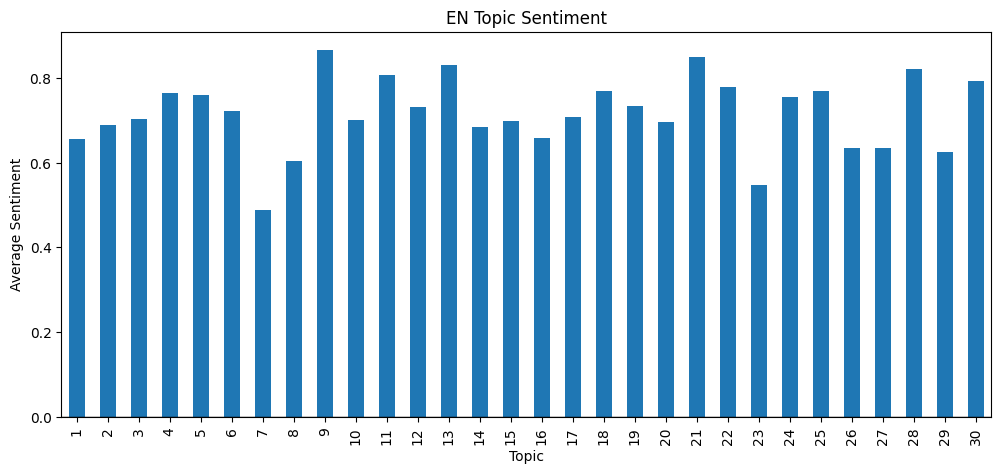

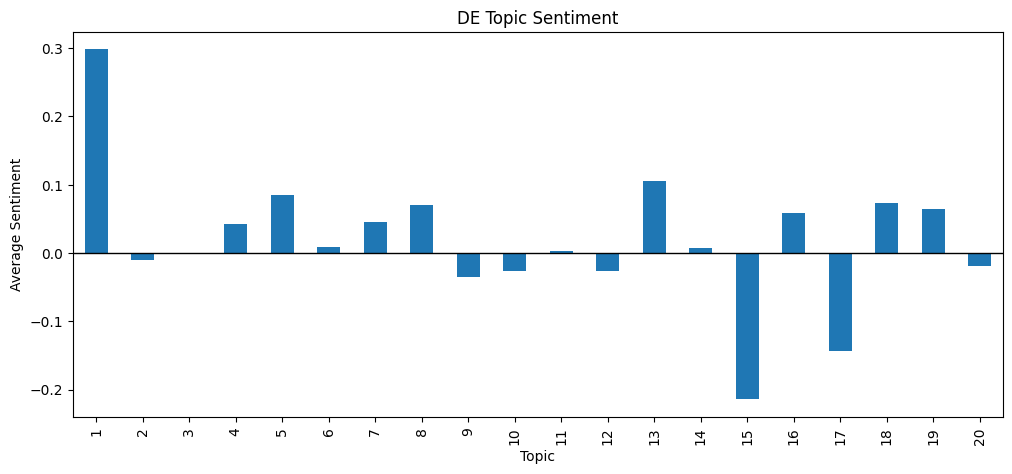

In [112]:
# Displays the average sentiment score for each topic.
# Purpose:
# - Identify topics with predominantly positive or negative sentiment.
# - Detect emotionally polarized topics.
# - Compare topics in terms of their semantic content and sentiment.

plot_topic_sentiment(
    topic_sentiment_summary["en"],
    title="EN Topic Sentiment"
)

plot_topic_sentiment(
    topic_sentiment_summary["de"],
    title="DE Topic Sentiment"
)

In [113]:
# Displays representative documents for a selected topic and sentiment class.
# Purpose:
# - Validate the semantic coherence of the discovered topic.
# - Assess whether the assigned documents match the topic keywords.
# - Verify whether the sentiment classification is consistent with the document content.
# - Support the qualitative evaluation of the topic model.
pd.set_option("display.max_colwidth", 1000)
show_reviews_for_topic(
    doc_topics_sentiment,
    lang="en",
    topic_id=1,
    sentiment_label="negative",
    n=10
)

,doc_id,dominant_topic,topic_strength,sentiment_score,sentiment_label,document_topic
469,469,1,0.279057,-0.8268,negative,short byob newtown square hit mark big portion decent price hungry fellini cafe bryn mawr memorable moment speed bump reach potential late past friday reservation wife arrive vacant table available seat break table instead put seater odd away kid bit privacy instead sit connect table manager move seater fine later member wait indication intention whisk bottle wine silverware run table eye contact simple follow hint shrug roll interior quaint lighting dim meal loud loud kid despite close quarter neighbor kid actually certain waitress extremely polite offer energy lack dinner order caesar salad share main course wife opt usual tagliatelli mushroom cream sauce tortellini pasticiatti meal piece bruschetta loaf crusty italian bread butter packet strange italian restaurant overall somewhat minor hiccup caesar salad warm plate salad legendary chilled warm plate frozen pea tortellini dish fine pea thaw pea thaw mar craft dish pay manager allow use expired card gesture require push induce f...
549,549,1,0.274150,-0.7717,negative,awefull zero star write absolute dining sake house esp family stay decide month old son sushi date arrive sake house table close sit immediately simple ice water lemon waiter later water order simple roll son start cold sake wait order settle min later water waiter hot sake instead cold later roll son finally cold sake request water cup son lemon table order order water perturb waiter check order finally nearly wait deal antsy son wait see chef order decide finally wait check drink reluctantly pay hospitality industry expect forgive english second language tough able wait table issue waiting deal fussy hungry toddler single mother offer drink understand accommodate principal waiste baby money waiste rare plan busy mother listen service money stay away
774,774,1,0.260650,-0.8750,negative,arado monday group shocked arrival sanitize large table quickly table smell sanitized rag buzz mean smell waiter appear drink order beer margarita margarita drinker group declare price drink mexican beer order bring fresh hot snarf tasty meet attentively quiet waiter let specific request bean light cheese meet kitchen belly red garter mind numb strip club wrap arado wrap decent shabby drink price cheap start affordable filling eat fountain square strip club
550,550,1,0.254998,-0.7506,negative,stage cool raise light sound system fog machine big dance floor service greet podium table figure sit wait employee menu see lady stop remember give certain kitchen close table kitchen closed kinda maybe stop order ahead exact lady seat table menu order bring freakin french fry sit watch eat french fry instead
700,700,1,0.251046,-0.8360,negative,seafood restaurant edge pear expectation set high wife order different plate menu order cioppino clam chowder crab salad sandwich clam chowder flavor consistency order cioppino lack flavor variety sea lack order pass crab salad sandwich lack flavor mayo overpower crab flavor non existent onion ring greasy order overall okay seat outside pear overlook ocean inside service prepared wait bit seat selective order menu tend hit miss
98,98,1,0.243113,-0.9337,negative,service management order waiter start manager offer drink cold eat half wait dine cracker barrel
41,41,1,0.235810,-0.9337,negative,straight point cheap taste cheap price location dessert edible item bake chicken fry chicken mashed potato salad bar meat cheese bar ravioli pizza waitress meh counter meat slicing station shrimp devein mexican station breakfast egg actually egg benedict cut ham english muffin occasion steak shrimp bread item decor nightmare imagine
313,313,1,0.226025,-0.9502,negative,han dynasty spot old mid atlantic restaurant unchanging menu han dynasty olde city maybe biased service check conversation hear peanut allergy peanut dish order han sister han dynasty month number note different branch different sp